# GVH Quantum Harmonic Oscillator Pipeline 0.1

## 1. Introduction physique

L’oscillateur harmonique quantique constitue l’un des systèmes fondamentaux de la mécanique quantique.

Il décrit une particule de masse \(m\) soumise à un potentiel quadratique :

\[
V(x)=\frac{1}{2}m\omega^2x^2
\]

où :

- \(x\) représente la position de la particule ;
- \(m\) représente sa masse ;
- \(\omega\) représente la pulsation propre du système ;
- \(V(x)\) représente l’énergie potentielle.

Le Hamiltonien du système est donné par :

\[
\hat{H}
=
-\frac{\hbar^2}{2m}
\frac{d^2}{dx^2}
+
\frac{1}{2}m\omega^2x^2
\]

L’équation de Schrödinger indépendante du temps s’écrit :

\[
\hat{H}\psi_n(x)
=
E_n\psi_n(x)
\]

où \(\psi_n(x)\) est la fonction d’onde associée au niveau quantique \(n\), et \(E_n\) son énergie.

Les niveaux d’énergie exacts sont :

\[
E_n
=
\hbar\omega
\left(
n+\frac{1}{2}
\right),
\qquad
n=0,1,2,\ldots
\]

Contrairement à un oscillateur classique, l’oscillateur quantique possède donc une énergie minimale non nulle :

\[
E_0=\frac{1}{2}\hbar\omega
\]

Cette énergie est appelée énergie du point zéro.

## 1.1 Pourquoi choisir ce système pour un premier test GVH ?

L’oscillateur harmonique quantique est particulièrement adapté à une première application microscopique du framework GVH pour plusieurs raisons :

1. ses solutions analytiques sont connues exactement ;
2. les fonctions d’onde sont normalisables ;
3. les niveaux d’énergie sont discrets ;
4. les états présentent une complexité croissante avec le nombre quantique \(n\) ;
5. les résultats numériques peuvent être comparés directement aux solutions théoriques ;
6. le système permet de tester la sensibilité des observables GVH aux changements de structure spatiale des fonctions d’onde.

Ce pipeline ne cherche pas à modifier l’interprétation physique standard de l’oscillateur harmonique.

Son objectif est d’évaluer si les observables GVH peuvent agir comme des descripteurs géométriques et dynamiques des états quantiques.

## 1.2 Objectif du pipeline

Le pipeline doit :

- générer plusieurs fonctions d’onde \(\psi_n(x)\) ;
- calculer les densités de probabilité :

\[
\rho_n(x)=|\psi_n(x)|^2
\]

- construire une représentation d’état compatible avec GVH ;
- mesurer les transitions entre points voisins ou entre niveaux quantiques ;
- calculer les observables GVH ;
- comparer les résultats selon le niveau quantique \(n\) ;
- vérifier la normalisation et la précision numérique.

## 1.3 Hypothèses de travail

Dans cette première version, on adopte des unités naturelles :

\[
\hbar=1,
\qquad
m=1,
\qquad
\omega=1
\]

Le potentiel devient alors :

\[
V(x)=\frac{1}{2}x^2
\]

et les niveaux d’énergie deviennent :

\[
E_n=n+\frac{1}{2}
\]

Cette convention simplifie les calculs sans modifier la structure mathématique du problème.

Le domaine spatial sera tronqué à un intervalle fini :

\[
x\in[-x_{\max},x_{\max}]
\]

avec une résolution suffisamment élevée pour que les fonctions d’onde soient pratiquement nulles aux limites.

## 1.4 États étudiés

La version 0.1 considérera les premiers niveaux quantiques :

\[
n=0,1,2,3,4,5
\]

Ces états permettent d’étudier progressivement :

- l’état fondamental sans nœud ;
- les états excités ;
- l’apparition de nœuds ;
- l’élargissement spatial des distributions ;
- l’évolution de la complexité géométrique.

## 1.5 Portée scientifique

Cette étude constitue un benchmark analytique microscopique.

Elle permettra de déterminer si les observables GVH :

- restent numériquement stables ;
- distinguent les différents états quantiques ;
- suivent l’évolution de la structure spatiale avec \(n\) ;
- sont robustes au choix de la résolution ;
- conservent une interprétation cohérente à l’échelle microscopique.

Un résultat positif ne constituerait pas une preuve d’une théorie quantique nouvelle ni d’une unification avec la gravité.

Il montrerait seulement que les descripteurs GVH peuvent être appliqués de manière cohérente à un système quantique analytique.

In [3]:
# ============================================================
# Configuration physique initiale
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import eval_hermite, factorial
from scipy.integrate import simpson

# Unités naturelles
hbar = 1.0
m = 1.0
omega = 1.0

# Domaine spatial
x_min = -8.0
x_max = 8.0
N_x = 4001

x = np.linspace(x_min, x_max, N_x)
dx = x[1] - x[0]

# Niveaux étudiés
niveaux = list(range(6))

print("Configuration initialisée")
print(f"Domaine spatial : [{x_min}, {x_max}]")
print(f"Nombre de points : {N_x}")
print(f"Pas spatial dx : {dx:.6f}")
print(f"Niveaux étudiés : {niveaux}")

Configuration initialisée
Domaine spatial : [-8.0, 8.0]
Nombre de points : 4001
Pas spatial dx : 0.004000
Niveaux étudiés : [0, 1, 2, 3, 4, 5]


# 2. Solution analytique de l’oscillateur harmonique

Pour l’oscillateur harmonique quantique unidimensionnel, les fonctions propres du Hamiltonien sont données par :

\[
\psi_n(x)
=
\frac{1}{\sqrt{2^n n!}}
\left(
\frac{m\omega}{\pi\hbar}
\right)^{1/4}
H_n(\xi)
\exp\left(-\frac{\xi^2}{2}\right)
\]

avec :

\[
\xi
=
\sqrt{\frac{m\omega}{\hbar}}\,x
\]

où \(H_n\) représente le polynôme d’Hermite d’ordre \(n\).

Les énergies propres sont :

\[
E_n
=
\hbar\omega
\left(
n+\frac{1}{2}
\right)
\]

Dans les unités naturelles adoptées dans ce notebook :

\[
\hbar=m=\omega=1
\]

on obtient :

\[
\xi=x
\]

et :

\[
\psi_n(x)
=
\frac{1}{\pi^{1/4}\sqrt{2^n n!}}
H_n(x)
\exp\left(-\frac{x^2}{2}\right)
\]

ainsi que :

\[
E_n=n+\frac{1}{2}
\]

Chaque fonction d’onde doit satisfaire la condition de normalisation :

\[
\int_{-\infty}^{+\infty}
|\psi_n(x)|^2\,dx
=
1
\]

Sur le domaine numérique fini utilisé ici, cette relation sera vérifiée par :

\[
\int_{-8}^{8}
|\psi_n(x)|^2\,dx
\approx 1
\]

La densité de probabilité associée à chaque état est :

\[
\rho_n(x)
=
|\psi_n(x)|^2
\]

In [4]:
# ============================================================
# Solution analytique de l’oscillateur harmonique quantique
# ============================================================

def fonction_onde_analytique(
    x: np.ndarray,
    n: int,
    m: float = 1.0,
    omega: float = 1.0,
    hbar: float = 1.0
) -> np.ndarray:
    """
    Calcule la fonction d'onde analytique psi_n(x)
    de l'oscillateur harmonique quantique 1D.

    Paramètres
    ----------
    x : np.ndarray
        Grille spatiale.
    n : int
        Nombre quantique, avec n >= 0.
    m : float
        Masse de la particule.
    omega : float
        Pulsation propre.
    hbar : float
        Constante de Planck réduite.

    Retour
    ------
    psi : np.ndarray
        Valeurs de la fonction d'onde psi_n(x).
    """

    if n < 0 or not isinstance(n, (int, np.integer)):
        raise ValueError("Le nombre quantique n doit être un entier positif ou nul.")

    if m <= 0:
        raise ValueError("La masse m doit être strictement positive.")

    if omega <= 0:
        raise ValueError("La pulsation omega doit être strictement positive.")

    if hbar <= 0:
        raise ValueError("La constante hbar doit être strictement positive.")

    # Variable adimensionnelle
    xi = np.sqrt(m * omega / hbar) * x

    # Polynôme d'Hermite H_n(xi)
    H_n = eval_hermite(n, xi)

    # Facteur de normalisation analytique
    normalisation = (
        (m * omega / (np.pi * hbar)) ** 0.25
        / np.sqrt((2.0 ** n) * factorial(n))
    )

    # Fonction d'onde
    psi = (
        normalisation
        * H_n
        * np.exp(-(xi ** 2) / 2.0)
    )

    return psi

In [5]:
def energie_analytique(
    n: int,
    omega: float = 1.0,
    hbar: float = 1.0
) -> float:
    """
    Retourne l'énergie analytique E_n.
    """

    if n < 0 or not isinstance(n, (int, np.integer)):
        raise ValueError("Le nombre quantique n doit être un entier positif ou nul.")

    if omega <= 0 or hbar <= 0:
        raise ValueError("omega et hbar doivent être strictement positifs.")

    return hbar * omega * (n + 0.5)

In [6]:
# ============================================================
# Test des solutions analytiques
# ============================================================

test_analytique = []

for n in niveaux:
    psi_n = fonction_onde_analytique(
        x=x,
        n=n,
        m=m,
        omega=omega,
        hbar=hbar
    )

    rho_n = np.abs(psi_n) ** 2

    norme_n = simpson(
        y=rho_n,
        x=x
    )

    energie_n = energie_analytique(
        n=n,
        omega=omega,
        hbar=hbar
    )

    test_analytique.append({
        "n": n,
        "E_n": energie_n,
        "Norme_numerique": norme_n,
        "Erreur_normalisation": abs(norme_n - 1.0),
        "psi_min": psi_n.min(),
        "psi_max": psi_n.max(),
        "rho_max": rho_n.max()
    })

test_analytique = pd.DataFrame(test_analytique)

display(test_analytique)

,n,E_n,Norme_numerique,Erreur_normalisation,psi_min,psi_max,rho_max
0,0,0.5,1.0,0.000000e+00,9.512378e-15,0.751126,0.564190
1,1,1.5,1.0,0.000000e+00,-6.442884e-01,0.644288,0.415107
2,2,2.5,1.0,0.000000e+00,-5.311260e-01,0.608680,0.370491
3,3,3.5,1.0,8.881784e-16,-5.878877e-01,0.587888,0.345612
4,4,4.5,1.0,6.661338e-16,-4.753838e-01,0.573409,0.328798
5,5,5.5,1.0,6.661338e-16,-5.623899e-01,0.562390,0.316282


# 3. Génération des fonctions d’onde

Les solutions analytiques sont maintenant regroupées dans une structure tabulaire unique.

Pour chaque niveau quantique \(n\), le pipeline conserve :

- la position \(x\) ;
- la fonction d’onde \(\psi_n(x)\) ;
- la densité de probabilité \(\rho_n(x)\) ;
- l’énergie \(E_n\) ;
- le potentiel harmonique \(V(x)\) ;
- la densité énergétique locale exploratoire \(E_n\rho_n(x)\).

Cette organisation permettra ensuite :

- de construire l’espace d’état GVH ;
- de comparer les niveaux quantiques ;
- de calculer les transitions spatiales ;
- de produire les observables GVH ;
- d’exporter les résultats dans un format reproductible.

In [7]:
# ============================================================
# Génération structurée des fonctions d’onde
# ============================================================

donnees_fonctions_onde = []

potentiel = 0.5 * m * omega**2 * x**2

for n in niveaux:
    psi_n = fonction_onde_analytique(
        x=x,
        n=n,
        m=m,
        omega=omega,
        hbar=hbar
    )

    rho_n = np.abs(psi_n) ** 2

    energie_n = energie_analytique(
        n=n,
        omega=omega,
        hbar=hbar
    )

    donnees_n = pd.DataFrame({
        "n": n,
        "x": x,
        "psi": psi_n,
        "rho": rho_n,
        "E_n": energie_n,
        "V_x": potentiel,
        "densite_energie": energie_n * rho_n
    })

    donnees_fonctions_onde.append(donnees_n)

fonctions_onde = pd.concat(
    donnees_fonctions_onde,
    ignore_index=True
)

print("Table des fonctions d’onde générée.")
print(f"Nombre total de lignes : {len(fonctions_onde)}")
print(f"Nombre de niveaux : {fonctions_onde['n'].nunique()}")

display(fonctions_onde.head())

Table des fonctions d’onde générée.
Nombre total de lignes : 24006
Nombre de niveaux : 6


,n,x,psi,rho,E_n,V_x,densite_energie
0,0,-8.000,9.512378e-15,9.048534e-29,0.5,32.000000,4.524267e-29
1,0,-7.996,9.821618e-15,9.646419e-29,0.5,31.968008,4.823209e-29
2,0,-7.992,1.014075e-14,1.028348e-28,0.5,31.936032,5.141740e-29
3,0,-7.988,1.047008e-14,1.096226e-28,0.5,31.904072,5.481132e-29
4,0,-7.984,1.080994e-14,1.168548e-28,0.5,31.872128,5.842738e-29


In [8]:
# ============================================================
# Contrôles de structure
# ============================================================

controle_structure = (
    fonctions_onde
    .groupby("n")
    .agg(
        N_points=("x", "size"),
        x_min=("x", "min"),
        x_max=("x", "max"),
        psi_min=("psi", "min"),
        psi_max=("psi", "max"),
        rho_min=("rho", "min"),
        rho_max=("rho", "max"),
        E_n=("E_n", "first")
    )
    .reset_index()
)

display(controle_structure)

,n,N_points,x_min,x_max,psi_min,psi_max,rho_min,rho_max,E_n
0,0,4001,-8.0,8.0,9.512378e-15,0.751126,9.048534e-29,0.564190,0.5
1,1,4001,-8.0,8.0,-6.442884e-01,0.644288,0.000000e+00,0.415107,1.5
2,2,4001,-8.0,8.0,-5.311260e-01,0.608680,7.297190e-25,0.370491,2.5
3,3,4001,-8.0,8.0,-5.878877e-01,0.587888,0.000000e+00,0.345612,3.5
4,4,4001,-8.0,8.0,-4.753838e-01,0.573409,9.197577e-22,0.328798,4.5
5,5,4001,-8.0,8.0,-5.623899e-01,0.562390,0.000000e+00,0.316282,5.5


In [9]:
# ============================================================
# Validation de l’intégrité des données
# ============================================================

nombre_nan = fonctions_onde.isna().sum().sum()

nombre_doublons = fonctions_onde.duplicated(
    subset=["n", "x"]
).sum()

print(f"Valeurs manquantes : {nombre_nan}")
print(f"Doublons (n, x) : {nombre_doublons}")

Valeurs manquantes : 0
Doublons (n, x) : 0


In [10]:
# ============================================================
# Vérification numérique de la parité
# ============================================================

controle_parite = []

for n in niveaux:
    psi_n = (
        fonctions_onde.loc[
            fonctions_onde["n"] == n,
            "psi"
        ]
        .to_numpy()
    )

    psi_inverse = psi_n[::-1]

    psi_attendue = ((-1) ** n) * psi_n

    erreur_parite = np.max(
        np.abs(psi_inverse - psi_attendue)
    )

    controle_parite.append({
        "n": n,
        "Parite_attendue": "paire" if n % 2 == 0 else "impaire",
        "Erreur_max_parite": erreur_parite
    })

controle_parite = pd.DataFrame(controle_parite)

display(controle_parite)

,n,Parite_attendue,Erreur_max_parite
0,0,paire,4.996004e-16
1,1,impaire,9.436896e-16
2,2,paire,1.144917e-15
3,3,impaire,1.235123e-15
4,4,paire,1.365661e-15
5,5,impaire,1.458469e-15


In [11]:
# ============================================================
# Comptage numérique des nœuds
# ============================================================

def compter_noeuds(psi: np.ndarray, seuil: float = 1e-10) -> int:
    """
    Compte les changements de signe significatifs de psi.
    """

    psi_filtre = psi.copy()
    psi_filtre[np.abs(psi_filtre) < seuil] = 0.0

    signes = np.sign(psi_filtre)
    signes_non_nuls = signes[signes != 0]

    if len(signes_non_nuls) < 2:
        return 0

    return int(
        np.sum(
            signes_non_nuls[1:] != signes_non_nuls[:-1]
        )
    )


controle_noeuds = []

for n in niveaux:
    psi_n = (
        fonctions_onde.loc[
            fonctions_onde["n"] == n,
            "psi"
        ]
        .to_numpy()
    )

    nombre_noeuds = compter_noeuds(psi_n)

    controle_noeuds.append({
        "n": n,
        "Noeuds_attendus": n,
        "Noeuds_detectes": nombre_noeuds,
        "Validation": nombre_noeuds == n
    })

controle_noeuds = pd.DataFrame(controle_noeuds)

display(controle_noeuds)

,n,Noeuds_attendus,Noeuds_detectes,Validation
0,0,0,0,True
1,1,1,1,True
2,2,2,2,True
3,3,3,3,True
4,4,4,4,True
5,5,5,5,True


# 4. Construction de l’espace d’état GVH

Pour appliquer les observables GVH, chaque point de la grille spatiale doit être représenté par un vecteur d’état.

Pour un niveau quantique \(n\) et une position \(x_i\), on définit :

\[
\mathbf{X}_{n,i}
=
\left(
\tilde{x}_i,
\tilde{\psi}_{n,i},
\tilde{\rho}_{n,i},
\widetilde{\partial_x\psi}_{n,i}
\right)
\]

avec :

\[
\rho_n(x)=|\psi_n(x)|^2
\]

et :

\[
\partial_x\psi_n(x)
=
\frac{d\psi_n}{dx}
\]

Les composantes sont rendues sans dimension avant le calcul des distances.

La position est normalisée globalement par :

\[
\tilde{x}
=
\frac{x}{x_{\max}}
\]

La fonction d’onde, la densité et la dérivée sont normalisées séparément pour chaque niveau quantique :

\[
\tilde{\psi}_n
=
\frac{\psi_n}{\max |\psi_n|}
\]

\[
\tilde{\rho}_n
=
\frac{\rho_n}{\max \rho_n}
\]

\[
\widetilde{\partial_x\psi}_n
=
\frac{\partial_x\psi_n}
{\max |\partial_x\psi_n|}
\]

Cette normalisation vise à empêcher une seule composante de dominer artificiellement la métrique euclidienne.

La transition spatiale entre deux points voisins est ensuite définie par :

\[
\Delta\mathbf{X}_{n,i}
=
\mathbf{X}_{n,i+1}
-
\mathbf{X}_{n,i}
\]

et sa norme par :

\[
D_{T,n,i}
=
\left\|
\Delta\mathbf{X}_{n,i}
\right\|_2
\]

Dans cette version 0.1, les transitions représentent donc des changements locaux le long de la coordonnée spatiale, et non une évolution temporelle réelle de l’état quantique.

In [12]:
# ============================================================
# Normalisation sécurisée
# ============================================================

def normaliser_max_abs(
    valeurs: np.ndarray,
    tolerance: float = 1e-15
) -> np.ndarray:
    """
    Normalise un tableau par sa valeur absolue maximale.

    Retourne un tableau nul lorsque l'échelle est trop petite.
    """

    valeurs = np.asarray(valeurs, dtype=float)

    echelle = np.max(np.abs(valeurs))

    if not np.isfinite(echelle):
        raise ValueError(
            "L'échelle de normalisation n'est pas finie."
        )

    if echelle < tolerance:
        return np.zeros_like(valeurs)

    return valeurs / echelle

In [13]:
# ============================================================
# Construction de l'espace d'état GVH
# ============================================================

espaces_etat = []

for n in niveaux:
    donnees_n = (
        fonctions_onde.loc[
            fonctions_onde["n"] == n
        ]
        .sort_values("x")
        .copy()
    )

    x_n = donnees_n["x"].to_numpy(dtype=float)
    psi_n = donnees_n["psi"].to_numpy(dtype=float)
    rho_n = donnees_n["rho"].to_numpy(dtype=float)

    # Dérivée numérique, avec gestion des bords
    dpsi_dx_n = np.gradient(
        psi_n,
        x_n,
        edge_order=2
    )

    # Normalisations
    x_norm = x_n / np.max(np.abs(x_n))
    psi_norm = normaliser_max_abs(psi_n)
    rho_norm = normaliser_max_abs(rho_n)
    dpsi_dx_norm = normaliser_max_abs(dpsi_dx_n)

    espace_n = pd.DataFrame({
        "n": n,
        "x": x_n,
        "E_n": donnees_n["E_n"].to_numpy(),
        "psi": psi_n,
        "rho": rho_n,
        "dpsi_dx": dpsi_dx_n,
        "x_norm": x_norm,
        "psi_norm": psi_norm,
        "rho_norm": rho_norm,
        "dpsi_dx_norm": dpsi_dx_norm
    })

    espaces_etat.append(espace_n)

espace_etat_gvh = pd.concat(
    espaces_etat,
    ignore_index=True
)

print("Espace d'état GVH construit.")
print(f"Nombre de lignes : {len(espace_etat_gvh)}")
print(f"Nombre de niveaux : {espace_etat_gvh['n'].nunique()}")

display(espace_etat_gvh.head())

Espace d'état GVH construit.
Nombre de lignes : 24006
Nombre de niveaux : 6


,n,x,E_n,psi,rho,dpsi_dx,x_norm,psi_norm,rho_norm,dpsi_dx_norm
0,0,-8.000,0.5,9.512378e-15,9.048534e-29,7.607370e-14,-1.0000,1.266417e-14,1.603811e-28,1.669827e-13
1,0,-7.996,0.5,9.821618e-15,9.646419e-29,7.854642e-14,-0.9995,1.307587e-14,1.709783e-28,1.724104e-13
2,0,-7.992,0.5,1.014075e-14,1.028348e-28,8.105803e-14,-0.9990,1.350074e-14,1.822699e-28,1.779234e-13
3,0,-7.988,0.5,1.047008e-14,1.096226e-28,8.364858e-14,-0.9985,1.393919e-14,1.943011e-28,1.836097e-13
4,0,-7.984,0.5,1.080994e-14,1.168548e-28,8.632053e-14,-0.9980,1.439165e-14,2.071197e-28,1.894747e-13


In [14]:
# ============================================================
# Contrôle de la normalisation
# ============================================================

controle_espace_etat = (
    espace_etat_gvh
    .groupby("n")
    .agg(
        N_points=("x", "size"),

        x_norm_min=("x_norm", "min"),
        x_norm_max=("x_norm", "max"),

        psi_norm_min=("psi_norm", "min"),
        psi_norm_max=("psi_norm", "max"),

        rho_norm_min=("rho_norm", "min"),
        rho_norm_max=("rho_norm", "max"),

        dpsi_norm_min=("dpsi_dx_norm", "min"),
        dpsi_norm_max=("dpsi_dx_norm", "max")
    )
    .reset_index()
)

display(controle_espace_etat)

,n,N_points,x_norm_min,x_norm_max,psi_norm_min,psi_norm_max,rho_norm_min,rho_norm_max,dpsi_norm_min,dpsi_norm_max
0,0,4001,-1.0,1.0,1.266417e-14,1.0,1.603811e-28,1.0,-1.000000,1.000000
1,1,4001,-1.0,1.0,-1.000000e+00,1.0,0.000000e+00,1.0,-0.446260,1.000000
2,2,4001,-1.0,1.0,-8.725872e-01,1.0,1.969601e-24,1.0,-1.000000,1.000000
3,3,4001,-1.0,1.0,-1.000000e+00,1.0,0.000000e+00,1.0,-1.000000,0.944735
4,4,4001,-1.0,1.0,-8.290480e-01,1.0,2.797332e-21,1.0,-1.000000,1.000000
5,5,4001,-1.0,1.0,-1.000000e+00,1.0,0.000000e+00,1.0,-0.978852,1.000000


In [15]:
# ============================================================
# Validation automatique de l'espace d'état
# ============================================================

colonnes_normalisees = [
    "x_norm",
    "psi_norm",
    "rho_norm",
    "dpsi_dx_norm"
]

valeurs_finies = np.isfinite(
    espace_etat_gvh[colonnes_normalisees].to_numpy()
).all()

bornes_respectees = (
    espace_etat_gvh[colonnes_normalisees]
    .abs()
    .max()
    .max()
    <= 1.0 + 1e-12
)

rho_positive = (
    espace_etat_gvh["rho_norm"].min()
    >= -1e-15
)

print(f"Toutes les valeurs sont finies : {valeurs_finies}")
print(f"Bornes [-1, 1] respectées : {bornes_respectees}")
print(f"Densité normalisée positive : {rho_positive}")

Toutes les valeurs sont finies : True
Bornes [-1, 1] respectées : True
Densité normalisée positive : True


In [16]:
# ============================================================
# Construction des transitions GVH locales
# ============================================================

composantes_etat = [
    "x_norm",
    "psi_norm",
    "rho_norm",
    "dpsi_dx_norm"
]

tables_transitions = []

for n in niveaux:
    etat_n = (
        espace_etat_gvh.loc[
            espace_etat_gvh["n"] == n
        ]
        .sort_values("x")
        .reset_index(drop=True)
    )

    matrice_etat = (
        etat_n[composantes_etat]
        .to_numpy(dtype=float)
    )

    # Différences entre points spatiaux consécutifs
    delta_etat = np.diff(
        matrice_etat,
        axis=0
    )

    # Norme euclidienne des transitions
    D_T = np.linalg.norm(
        delta_etat,
        axis=1
    )

    transitions_n = pd.DataFrame({
        "n": n,
        "E_n": etat_n["E_n"].iloc[:-1].to_numpy(),
        "x_debut": etat_n["x"].iloc[:-1].to_numpy(),
        "x_fin": etat_n["x"].iloc[1:].to_numpy(),

        "delta_x_norm": delta_etat[:, 0],
        "delta_psi_norm": delta_etat[:, 1],
        "delta_rho_norm": delta_etat[:, 2],
        "delta_dpsi_dx_norm": delta_etat[:, 3],

        "D_T": D_T
    })

    tables_transitions.append(transitions_n)

transitions_gvh = pd.concat(
    tables_transitions,
    ignore_index=True
)

print("Transitions GVH construites.")
print(f"Nombre total de transitions : {len(transitions_gvh)}")
print(
    "Transitions par niveau :",
    transitions_gvh.groupby("n").size().to_dict()
)

display(transitions_gvh.head())

Transitions GVH construites.
Nombre total de transitions : 24000
Transitions par niveau : {0: 4000, 1: 4000, 2: 4000, 3: 4000, 4: 4000, 5: 4000}


,n,E_n,x_debut,x_fin,delta_x_norm,delta_psi_norm,delta_rho_norm,delta_dpsi_dx_norm,D_T
0,0,0.5,-8.000,-7.996,0.0005,4.117025e-16,1.059724e-29,5.427670e-15,0.0005
1,0,0.5,-7.996,-7.992,0.0005,4.248706e-16,1.129162e-29,5.513002e-15,0.0005
2,0,0.5,-7.992,-7.988,0.0005,4.384528e-16,1.203111e-29,5.686303e-15,0.0005
3,0,0.5,-7.988,-7.984,0.0005,4.524618e-16,1.281862e-29,5.864954e-15,0.0005
4,0,0.5,-7.984,-7.980,0.0005,4.669108e-16,1.365724e-29,6.049117e-15,0.0005


In [17]:
# ============================================================
# Validation des transitions
# ============================================================

controle_transitions = (
    transitions_gvh
    .groupby("n")
    .agg(
        N_transitions=("D_T", "size"),
        D_T_min=("D_T", "min"),
        D_T_mean=("D_T", "mean"),
        D_T_max=("D_T", "max"),
        D_T_std=("D_T", "std")
    )
    .reset_index()
)

display(controle_transitions)

print(
    "Valeurs D_T finies :",
    np.isfinite(transitions_gvh["D_T"]).all()
)

print(
    "Distances D_T positives ou nulles :",
    (transitions_gvh["D_T"] >= 0).all()
)

print(
    "Nombre total attendu respecté :",
    len(transitions_gvh) == 24000
)

,n,N_transitions,D_T_min,D_T_mean,D_T_max,D_T_std
0,0,4000,0.0005,0.001661,0.006614,0.001802
1,1,4000,0.0005,0.002171,0.009175,0.002555
2,2,4000,0.0005,0.002971,0.010784,0.003447
3,3,4000,0.0005,0.003690,0.012265,0.004099
4,4,4000,0.0005,0.004420,0.013436,0.004683
5,5,4000,0.0005,0.005110,0.014505,0.005156


Valeurs D_T finies : True
Distances D_T positives ou nulles : True
Nombre total attendu respecté : True


# 5. Calcul des observables GVH

Les observables GVH sont calculées séparément pour chaque niveau quantique.

## 5.1 Observables de distance

La distance moyenne de transition est :

\[
D_{T,\mathrm{mean}}
=
\frac{1}{N_T}
\sum_{i=1}^{N_T}D_{T,i}
\]

La dispersion des transitions est :

\[
S_T
=
\operatorname{std}(D_T)
\]

et sa version relative :

\[
S_{T,\mathrm{norm}}
=
\frac{S_T}{D_{T,\mathrm{mean}}}
\]

Le seuil critique brut est défini comme le quantile \(q\) de la distribution :

\[
D_c
=
Q_q(D_T)
\]

Dans cette version, on adopte :

\[
q=0.95
\]

Les distances sont ensuite normalisées par leur maximum :

\[
u_i
=
\frac{D_{T,i}}{\max(D_T)}
\]

Le seuil normalisé correspondant est :

\[
u_c
=
Q_q(u)
\]

La proportion de transitions au-dessus du seuil est :

\[
R_{\mathrm{super}}
=
\frac{1}{N_T}
\sum_i
\mathbf{1}_{u_i>u_c}
\]

Avec un quantile à 95 %, cette proportion doit être proche de 0.05, sauf en présence de valeurs répétées au seuil.

## 5.2 Fonction de survie

La fonction de survie empirique est définie par :

\[
R_{\mathrm{super}}(d)
=
P(u>d)
\]

Une loi exponentielle exploratoire est ajustée :

\[
R_{\mathrm{super}}(d)
=
A_H\exp(-B_Hd)
\]

Les paramètres \(A_H\) et \(B_H\) décrivent respectivement l’amplitude et le taux d’atténuation de la fonction de survie.

Cet ajustement est descriptif. Sa qualité doit être contrôlée avant toute interprétation physique.

## 5.3 Observables angulaires

Pour deux transitions successives non nulles,

\[
\Delta\mathbf{X}_i
\quad\text{et}\quad
\Delta\mathbf{X}_{i+1},
\]

l’angle est défini par :

\[
\theta_i
=
\arccos
\left(
\frac{
\Delta\mathbf{X}_i\cdot\Delta\mathbf{X}_{i+1}
}{
\|\Delta\mathbf{X}_i\|
\|\Delta\mathbf{X}_{i+1}\|
}
\right)
\]

Les angles sont exprimés en degrés.

Nous calculons :

- \(\theta_{\mathrm{mean}}\) ;
- \(\theta_{\mathrm{median}}\) ;
- \(\theta_{\mathrm{std}}\) ;
- \(\theta_{\mathrm{max}}\) ;
- \(R_{170}\), proportion des angles supérieurs ou égaux à \(170^\circ\).

Dans ce pipeline stationnaire, ces angles mesurent les changements de direction de la trajectoire spatiale dans l’espace d’état GVH. Ils ne représentent pas une évolution temporelle.

In [18]:
# ============================================================
# Imports et paramètres des observables GVH
# ============================================================

from scipy.optimize import curve_fit

quantile_critique = 0.95
seuil_angle_deg = 170.0

# Évite les divisions par des normes numériquement nulles
epsilon_norme = 1e-15

print(f"Quantile critique q : {quantile_critique}")
print(f"Seuil angulaire : {seuil_angle_deg} degrés")

Quantile critique q : 0.95
Seuil angulaire : 170.0 degrés


In [19]:
# ============================================================
# Modèle exponentiel de survie
# ============================================================

def modele_survie_exponentielle(
    d: np.ndarray,
    A_H: float,
    B_H: float
) -> np.ndarray:
    """
    Modèle exponentiel :
        R(d) = A_H * exp(-B_H * d)
    """

    return A_H * np.exp(-B_H * d)

In [20]:
# ============================================================
# Fonction de survie empirique
# ============================================================

def construire_survie_empirique(
    u: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """
    Construit la fonction de survie empirique P(u > d).

    Retour
    ------
    d : np.ndarray
        Seuils normalisés.
    survie : np.ndarray
        Proportion des observations strictement supérieures
        à chaque seuil.
    """

    u = np.asarray(u, dtype=float)

    if u.ndim != 1:
        raise ValueError("u doit être un tableau unidimensionnel.")

    if len(u) == 0:
        raise ValueError("u ne peut pas être vide.")

    if not np.isfinite(u).all():
        raise ValueError("u contient des valeurs non finies.")

    d = np.unique(np.sort(u))

    survie = np.array([
        np.mean(u > seuil)
        for seuil in d
    ])

    return d, survie

In [21]:
# ============================================================
# Ajustement exponentiel sécurisé
# ============================================================

def ajuster_survie_exponentielle(
    d: np.ndarray,
    survie: np.ndarray
) -> dict:
    """
    Ajuste le modèle A_H * exp(-B_H*d).

    Retourne également R² et RMSE pour contrôler
    la qualité descriptive de l'ajustement.
    """

    d = np.asarray(d, dtype=float)
    survie = np.asarray(survie, dtype=float)

    masque = (
        np.isfinite(d)
        & np.isfinite(survie)
        & (survie > 0.0)
    )

    d_fit = d[masque]
    survie_fit = survie[masque]

    if len(d_fit) < 3:
        return {
            "A_H": np.nan,
            "B_H": np.nan,
            "Survie_R2": np.nan,
            "Survie_RMSE": np.nan,
            "N_fit": len(d_fit)
        }

    try:
        parametres, _ = curve_fit(
            modele_survie_exponentielle,
            d_fit,
            survie_fit,
            p0=(1.0, 5.0),
            bounds=(
                [0.0, 0.0],
                [np.inf, np.inf]
            ),
            maxfev=50000
        )

        A_H, B_H = parametres

        prediction = modele_survie_exponentielle(
            d_fit,
            A_H,
            B_H
        )

        residus = survie_fit - prediction

        ss_res = np.sum(residus**2)
        ss_tot = np.sum(
            (survie_fit - np.mean(survie_fit))**2
        )

        if ss_tot > 0:
            r2 = 1.0 - ss_res / ss_tot
        else:
            r2 = np.nan

        rmse = np.sqrt(
            np.mean(residus**2)
        )

        return {
            "A_H": float(A_H),
            "B_H": float(B_H),
            "Survie_R2": float(r2),
            "Survie_RMSE": float(rmse),
            "N_fit": int(len(d_fit))
        }

    except (RuntimeError, ValueError, FloatingPointError):
        return {
            "A_H": np.nan,
            "B_H": np.nan,
            "Survie_R2": np.nan,
            "Survie_RMSE": np.nan,
            "N_fit": int(len(d_fit))
        }

In [22]:
# ============================================================
# Angles entre transitions successives
# ============================================================

def calculer_angles_transitions(
    delta_etat: np.ndarray,
    epsilon: float = 1e-15
) -> np.ndarray:
    """
    Calcule les angles, en degrés, entre les vecteurs
    de transition successifs.
    """

    delta_etat = np.asarray(
        delta_etat,
        dtype=float
    )

    if delta_etat.ndim != 2:
        raise ValueError(
            "delta_etat doit être une matrice 2D."
        )

    if len(delta_etat) < 2:
        return np.array([], dtype=float)

    vecteurs_1 = delta_etat[:-1]
    vecteurs_2 = delta_etat[1:]

    normes_1 = np.linalg.norm(
        vecteurs_1,
        axis=1
    )

    normes_2 = np.linalg.norm(
        vecteurs_2,
        axis=1
    )

    masque_valide = (
        (normes_1 > epsilon)
        & (normes_2 > epsilon)
    )

    if not np.any(masque_valide):
        return np.array([], dtype=float)

    produits_scalaires = np.sum(
        vecteurs_1[masque_valide]
        * vecteurs_2[masque_valide],
        axis=1
    )

    cosinus = (
        produits_scalaires
        / (
            normes_1[masque_valide]
            * normes_2[masque_valide]
        )
    )

    # Protection contre les légers dépassements numériques
    cosinus = np.clip(
        cosinus,
        -1.0,
        1.0
    )

    angles = np.degrees(
        np.arccos(cosinus)
    )

    return angles

In [23]:
# ============================================================
# Calcul complet des observables GVH
# ============================================================

observables_gvh = []
survies_gvh = []
angles_gvh = []

colonnes_delta = [
    "delta_x_norm",
    "delta_psi_norm",
    "delta_rho_norm",
    "delta_dpsi_dx_norm"
]

for n in niveaux:
    transitions_n = (
        transitions_gvh.loc[
            transitions_gvh["n"] == n
        ]
        .sort_values("x_debut")
        .reset_index(drop=True)
    )

    D_T = transitions_n["D_T"].to_numpy(
        dtype=float
    )

    delta_etat = transitions_n[
        colonnes_delta
    ].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Observables de distance
    # --------------------------------------------------------

    D_T_mean = np.mean(D_T)

    # ddof=0 : écart-type de la population complète
    S_T = np.std(
        D_T,
        ddof=0
    )

    S_T_norm = (
        S_T / D_T_mean
        if D_T_mean > epsilon_norme
        else np.nan
    )

    D_T_max = np.max(D_T)

    if D_T_max > epsilon_norme:
        u = D_T / D_T_max
    else:
        u = np.zeros_like(D_T)

    D_c = np.quantile(
        D_T,
        quantile_critique
    )

    u_c = np.quantile(
        u,
        quantile_critique
    )

    R_super = np.mean(
        u > u_c
    )

    # --------------------------------------------------------
    # Fonction de survie
    # --------------------------------------------------------

    d_survie, R_survie = construire_survie_empirique(u)

    ajustement = ajuster_survie_exponentielle(
        d_survie,
        R_survie
    )

    table_survie_n = pd.DataFrame({
        "n": n,
        "d": d_survie,
        "R_survie_empirique": R_survie,
        "R_survie_exponentielle":
            modele_survie_exponentielle(
                d_survie,
                ajustement["A_H"],
                ajustement["B_H"]
            )
            if np.isfinite(ajustement["A_H"])
            else np.nan
    })

    survies_gvh.append(table_survie_n)

    # --------------------------------------------------------
    # Observables angulaires
    # --------------------------------------------------------

    angles = calculer_angles_transitions(
        delta_etat,
        epsilon=epsilon_norme
    )

    if len(angles) > 0:
        theta_mean = np.mean(angles)
        theta_median = np.median(angles)
        theta_std = np.std(angles, ddof=0)
        theta_max = np.max(angles)
        R_170 = np.mean(
            angles >= seuil_angle_deg
        )
    else:
        theta_mean = np.nan
        theta_median = np.nan
        theta_std = np.nan
        theta_max = np.nan
        R_170 = np.nan

    table_angles_n = pd.DataFrame({
        "n": n,
        "indice_angle": np.arange(len(angles)),
        "theta_deg": angles
    })

    angles_gvh.append(table_angles_n)

    # --------------------------------------------------------
    # Résumé du niveau
    # --------------------------------------------------------

    observables_gvh.append({
        "n": n,
        "E_n": transitions_n["E_n"].iloc[0],
        "N_transitions": len(D_T),
        "N_angles": len(angles),

        "D_T_min": np.min(D_T),
        "D_T_mean": D_T_mean,
        "D_T_max": D_T_max,

        "S_T": S_T,
        "S_T_norm": S_T_norm,

        "D_c": D_c,
        "u_c": u_c,
        "R_super": R_super,

        "A_H": ajustement["A_H"],
        "B_H": ajustement["B_H"],
        "Survie_R2": ajustement["Survie_R2"],
        "Survie_RMSE": ajustement["Survie_RMSE"],
        "N_survie_fit": ajustement["N_fit"],

        "theta_mean": theta_mean,
        "theta_median": theta_median,
        "theta_std": theta_std,
        "theta_max": theta_max,
        "R_170": R_170
    })

observables_gvh = pd.DataFrame(
    observables_gvh
)

survies_gvh = pd.concat(
    survies_gvh,
    ignore_index=True
)

angles_gvh = pd.concat(
    angles_gvh,
    ignore_index=True
)

display(observables_gvh)

,n,E_n,N_transitions,N_angles,D_T_min,D_T_mean,D_T_max,S_T,S_T_norm,D_c,...,A_H,B_H,Survie_R2,Survie_RMSE,N_survie_fit,theta_mean,theta_median,theta_std,theta_max,R_170
0,0,0.5,4000,3999,0.0005,0.001661,0.006614,0.001802,1.084931,0.005996,...,0.755617,3.034277,0.810582,0.106037,3107,0.122724,0.053293,0.148311,0.491847,0.0
1,1,1.5,4000,3999,0.0005,0.002171,0.009175,0.002555,1.176946,0.008200,...,0.737087,3.143143,0.820069,0.106080,3210,0.173528,0.110640,0.214583,0.860650,0.0
2,2,2.5,4000,3999,0.0005,0.002971,0.010784,0.003447,1.160259,0.010278,...,0.740349,2.555393,0.847435,0.101038,3369,0.230714,0.173593,0.272793,1.029686,0.0
3,3,3.5,4000,3999,0.0005,0.003690,0.012265,0.004099,1.110716,0.011305,...,0.758963,2.298678,0.865000,0.097845,3492,0.287031,0.213564,0.324726,1.244734,0.0
4,4,4.5,4000,3999,0.0005,0.004420,0.013436,0.004683,1.059392,0.012628,...,0.782248,2.104336,0.878610,0.095529,3624,0.342261,0.258225,0.367575,1.377382,0.0
5,5,5.5,4000,3999,0.0005,0.005110,0.014505,0.005155,1.008795,0.013743,...,0.804142,1.975311,0.888334,0.093431,3709,0.397142,0.297154,0.406430,1.532871,0.0


In [24]:
# ============================================================
# Tableau principal des observables demandées
# ============================================================

colonnes_principales = [
    "n",
    "E_n",
    "D_T_mean",
    "S_T",
    "S_T_norm",
    "D_c",
    "u_c",
    "R_super",
    "A_H",
    "B_H",
    "theta_mean",
    "theta_median",
    "theta_std",
    "theta_max",
    "R_170"
]

observables_gvh_principales = (
    observables_gvh[colonnes_principales]
    .copy()
)

display(observables_gvh_principales)

,n,E_n,D_T_mean,S_T,S_T_norm,D_c,u_c,R_super,A_H,B_H,theta_mean,theta_median,theta_std,theta_max,R_170
0,0,0.5,0.001661,0.001802,1.084931,0.005996,0.906599,0.05,0.755617,3.034277,0.122724,0.053293,0.148311,0.491847,0.0
1,1,1.5,0.002171,0.002555,1.176946,0.008200,0.893770,0.05,0.737087,3.143143,0.173528,0.110640,0.214583,0.860650,0.0
2,2,2.5,0.002971,0.003447,1.160259,0.010278,0.953037,0.05,0.740349,2.555393,0.230714,0.173593,0.272793,1.029686,0.0
3,3,3.5,0.003690,0.004099,1.110716,0.011305,0.921718,0.05,0.758963,2.298678,0.287031,0.213564,0.324726,1.244734,0.0
4,4,4.5,0.004420,0.004683,1.059392,0.012628,0.939879,0.05,0.782248,2.104336,0.342261,0.258225,0.367575,1.377382,0.0
5,5,5.5,0.005110,0.005155,1.008795,0.013743,0.947432,0.05,0.804142,1.975311,0.397142,0.297154,0.406430,1.532871,0.0


In [25]:
# ============================================================
# Validation automatique des observables GVH
# ============================================================

colonnes_distance = [
    "D_T_mean",
    "S_T",
    "S_T_norm",
    "D_c",
    "u_c",
    "R_super"
]

colonnes_angles = [
    "theta_mean",
    "theta_median",
    "theta_std",
    "theta_max",
    "R_170"
]

distances_finies = np.isfinite(
    observables_gvh[colonnes_distance].to_numpy()
).all()

angles_finis = np.isfinite(
    observables_gvh[colonnes_angles].to_numpy()
).all()

u_c_valide = (
    observables_gvh["u_c"]
    .between(0.0, 1.0)
    .all()
)

R_super_valide = (
    observables_gvh["R_super"]
    .between(0.0, 1.0)
    .all()
)

angles_valides = (
    observables_gvh[
        [
            "theta_mean",
            "theta_median",
            "theta_max"
        ]
    ]
    .ge(0.0)
    .all()
    .all()
    and
    observables_gvh[
        [
            "theta_mean",
            "theta_median",
            "theta_max"
        ]
    ]
    .le(180.0)
    .all()
    .all()
)

R_170_valide = (
    observables_gvh["R_170"]
    .between(0.0, 1.0)
    .all()
)

nombre_transitions_valide = (
    observables_gvh["N_transitions"]
    .eq(4000)
    .all()
)

nombre_angles_valide = (
    observables_gvh["N_angles"]
    .eq(3999)
    .all()
)

print(f"Observables de distance finies : {distances_finies}")
print(f"Observables angulaires finies : {angles_finis}")
print(f"u_c dans [0, 1] : {u_c_valide}")
print(f"R_super dans [0, 1] : {R_super_valide}")
print(f"Angles dans [0°, 180°] : {angles_valides}")
print(f"R_170 dans [0, 1] : {R_170_valide}")
print(f"4000 transitions par niveau : {nombre_transitions_valide}")
print(f"3999 angles par niveau : {nombre_angles_valide}")

Observables de distance finies : True
Observables angulaires finies : True
u_c dans [0, 1] : True
R_super dans [0, 1] : True
Angles dans [0°, 180°] : True
R_170 dans [0, 1] : True
4000 transitions par niveau : True
3999 angles par niveau : True


In [26]:
# ============================================================
# Tendances selon le niveau quantique
# ============================================================

controle_tendances = observables_gvh[
    [
        "n",
        "E_n",
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_c",
        "u_c",
        "R_super",
        "B_H",
        "theta_mean",
        "theta_max",
        "R_170"
    ]
].copy()

controle_tendances["Delta_D_T_mean"] = (
    controle_tendances["D_T_mean"].diff()
)

controle_tendances["D_T_mean_croissant"] = (
    controle_tendances["Delta_D_T_mean"] > 0
)

display(controle_tendances)

,n,E_n,D_T_mean,S_T,S_T_norm,D_c,u_c,R_super,B_H,theta_mean,theta_max,R_170,Delta_D_T_mean,D_T_mean_croissant
0,0,0.5,0.001661,0.001802,1.084931,0.005996,0.906599,0.05,3.034277,0.122724,0.491847,0.0,NaN,False
1,1,1.5,0.002171,0.002555,1.176946,0.008200,0.893770,0.05,3.143143,0.173528,0.860650,0.0,0.000510,True
2,2,2.5,0.002971,0.003447,1.160259,0.010278,0.953037,0.05,2.555393,0.230714,1.029686,0.0,0.000800,True
3,3,3.5,0.003690,0.004099,1.110716,0.011305,0.921718,0.05,2.298678,0.287031,1.244734,0.0,0.000719,True
4,4,4.5,0.004420,0.004683,1.059392,0.012628,0.939879,0.05,2.104336,0.342261,1.377382,0.0,0.000730,True
5,5,5.5,0.005110,0.005155,1.008795,0.013743,0.947432,0.05,1.975311,0.397142,1.532871,0.0,0.000690,True


# 6. Visualisation des résultats GVH

Cette section représente :

1. les fonctions d’onde analytiques ;
2. les densités de probabilité ;
3. les distances de transition \(D_T(x)\) ;
4. les fonctions de survie empiriques et exponentielles ;
5. l’évolution des observables avec le niveau quantique.

Les graphiques permettent de vérifier visuellement que les observables GVH suivent la structure spatiale des états quantiques.

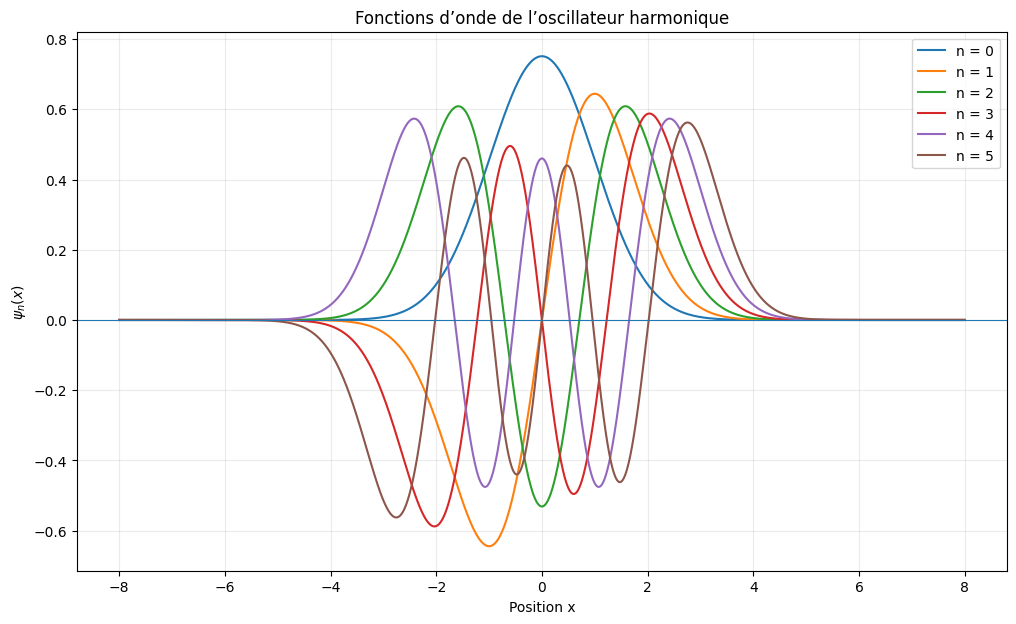

In [ ]:
plt.figure(figsize=(12, 7))

for n in niveaux:
    donnees_n = fonctions_onde[
        fonctions_onde["n"] == n
    ]

    plt.plot(
        donnees_n["x"],
        donnees_n["psi"],
        label=f"n = {n}"
    )

plt.axhline(0.0, linewidth=0.8)
plt.xlabel("Position x")
plt.ylabel(r"$\psi_n(x)$")
plt.title("Fonctions d’onde de l’oscillateur harmonique")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

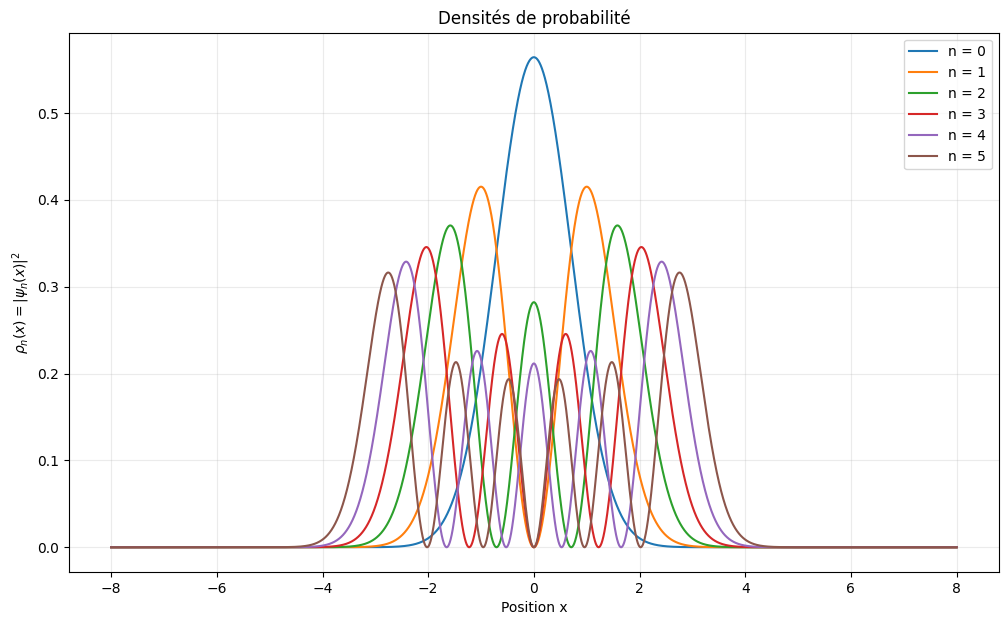

In [27]:
plt.figure(figsize=(12, 7))

for n in niveaux:
    donnees_n = fonctions_onde[
        fonctions_onde["n"] == n
    ]

    plt.plot(
        donnees_n["x"],
        donnees_n["rho"],
        label=f"n = {n}"
    )

plt.xlabel("Position x")
plt.ylabel(r"$\rho_n(x)=|\psi_n(x)|^2$")
plt.title("Densités de probabilité")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

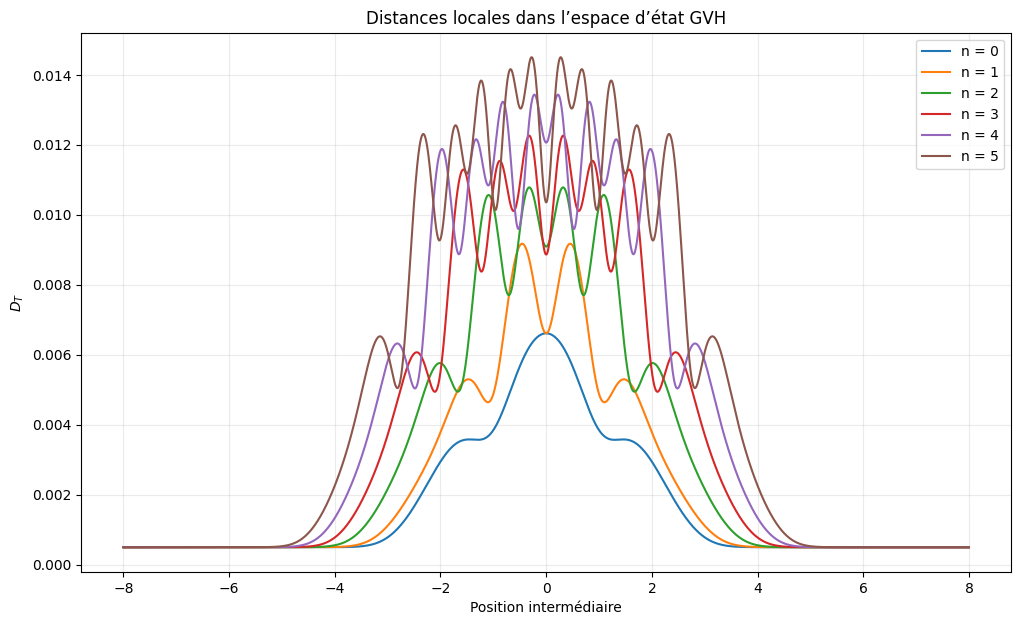

In [28]:
plt.figure(figsize=(12, 7))

for n in niveaux:
    transitions_n = transitions_gvh[
        transitions_gvh["n"] == n
    ]

    x_milieu = (
        transitions_n["x_debut"].to_numpy()
        + transitions_n["x_fin"].to_numpy()
    ) / 2.0

    plt.plot(
        x_milieu,
        transitions_n["D_T"],
        label=f"n = {n}"
    )

plt.xlabel("Position intermédiaire")
plt.ylabel(r"$D_T$")
plt.title("Distances locales dans l’espace d’état GVH")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

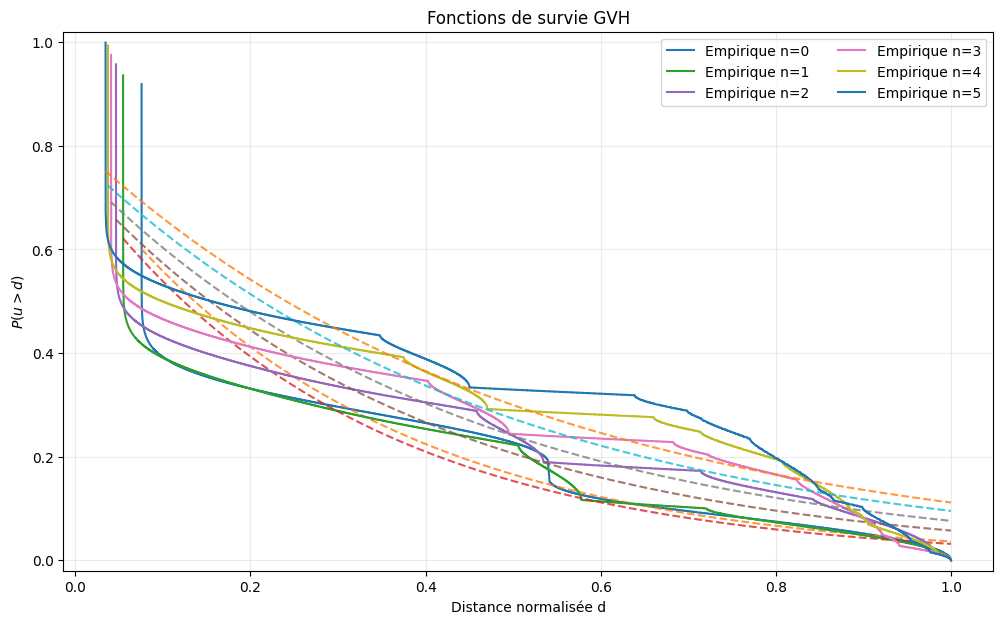

In [29]:
plt.figure(figsize=(12, 7))

for n in niveaux:
    survie_n = survies_gvh[
        survies_gvh["n"] == n
    ]

    plt.plot(
        survie_n["d"],
        survie_n["R_survie_empirique"],
        label=f"Empirique n={n}"
    )

    plt.plot(
        survie_n["d"],
        survie_n["R_survie_exponentielle"],
        linestyle="--",
        alpha=0.8
    )

plt.xlabel("Distance normalisée d")
plt.ylabel(r"$P(u>d)$")
plt.title("Fonctions de survie GVH")
plt.ylim(-0.02, 1.02)
plt.legend(ncol=2)
plt.grid(alpha=0.25)
plt.show()

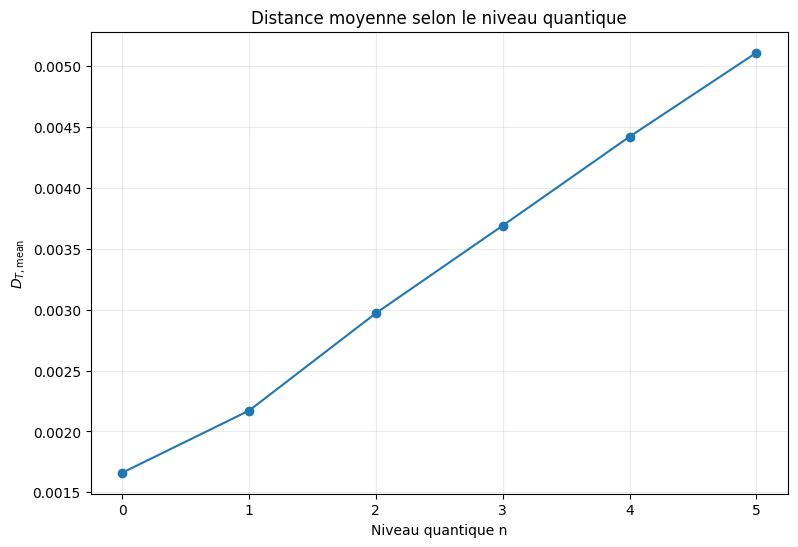

In [30]:
plt.figure(figsize=(9, 6))

plt.plot(
    observables_gvh["n"],
    observables_gvh["D_T_mean"],
    marker="o"
)

plt.xlabel("Niveau quantique n")
plt.ylabel(r"$D_{T,\mathrm{mean}}$")
plt.title("Distance moyenne selon le niveau quantique")
plt.xticks(niveaux)
plt.grid(alpha=0.25)
plt.show()

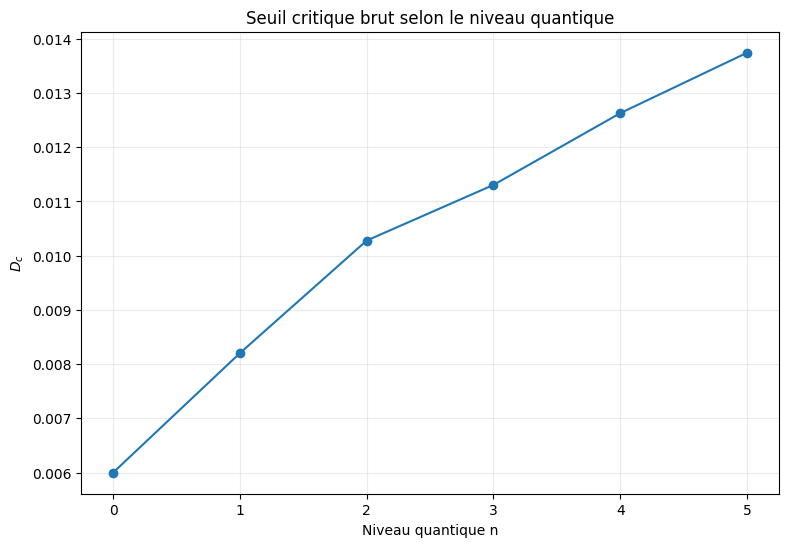

In [31]:
plt.figure(figsize=(9, 6))

plt.plot(
    observables_gvh["n"],
    observables_gvh["D_c"],
    marker="o"
)

plt.xlabel("Niveau quantique n")
plt.ylabel(r"$D_c$")
plt.title("Seuil critique brut selon le niveau quantique")
plt.xticks(niveaux)
plt.grid(alpha=0.25)
plt.show()

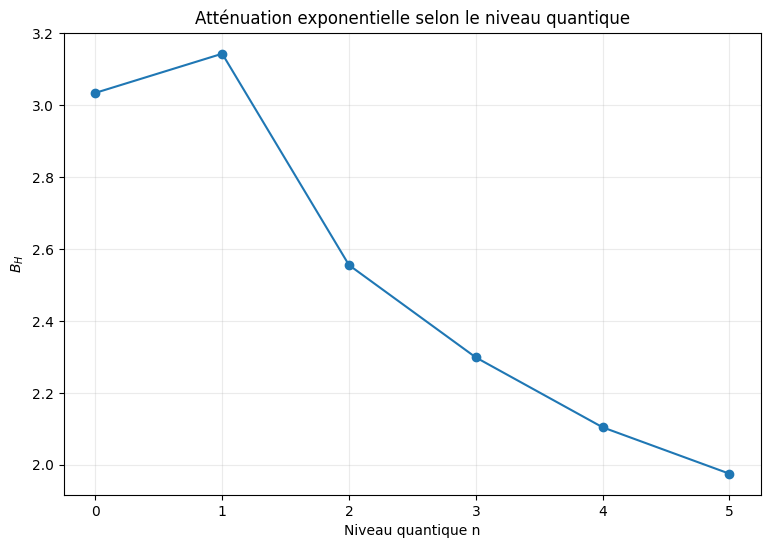

In [32]:
plt.figure(figsize=(9, 6))

plt.plot(
    observables_gvh["n"],
    observables_gvh["B_H"],
    marker="o"
)

plt.xlabel("Niveau quantique n")
plt.ylabel(r"$B_H$")
plt.title("Atténuation exponentielle selon le niveau quantique")
plt.xticks(niveaux)
plt.grid(alpha=0.25)
plt.show()

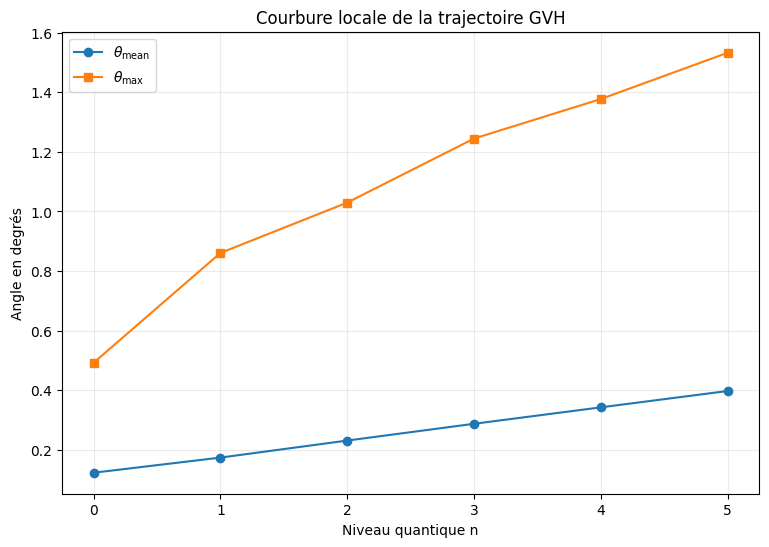

In [33]:
plt.figure(figsize=(9, 6))

plt.plot(
    observables_gvh["n"],
    observables_gvh["theta_mean"],
    marker="o",
    label=r"$\theta_{\mathrm{mean}}$"
)

plt.plot(
    observables_gvh["n"],
    observables_gvh["theta_max"],
    marker="s",
    label=r"$\theta_{\max}$"
)

plt.xlabel("Niveau quantique n")
plt.ylabel("Angle en degrés")
plt.title("Courbure locale de la trajectoire GVH")
plt.xticks(niveaux)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 7. Validation numérique et robustesse

Les observables GVH dépendent de différences entre points voisins. Elles peuvent donc être sensibles :

- au pas spatial \(\Delta x\) ;
- au nombre de points \(N_x\) ;
- à la largeur du domaine \([-L,L]\) ;
- à la normalisation des composantes de l’espace d’état.

Cette section étudie séparément :

1. la convergence avec la résolution spatiale ;
2. la stabilité avec la largeur du domaine ;
3. les écarts relatifs à une configuration de référence ;
4. la conservation des tendances entre les niveaux quantiques.

Une observable est considérée comme numériquement stable lorsque sa variation relative diminue avec le raffinement de la grille ou l’agrandissement raisonnable du domaine.

Dans ce pipeline, les distances sont calculées entre points voisins. Leur valeur brute dépend naturellement de \(\Delta x\). Nous examinerons donc à la fois :

\[
D_{T,\mathrm{mean}}
\]

et une version corrigée du pas :

\[
D_{T,\mathrm{dens}}
=
\frac{D_{T,\mathrm{mean}}}{\Delta x}
\]

La première mesure la transition par pas de grille. La seconde estime une intensité de variation par unité spatiale.

In [34]:
# ============================================================
# Recalcul des observables pour une configuration numérique
# ============================================================

def calculer_observables_configuration(
    n: int,
    L: float,
    N_points: int,
    quantile: float = 0.95,
    epsilon: float = 1e-15
) -> dict:
    """
    Recalcule les principales observables GVH d'un niveau n
    pour un domaine [-L, L] et une grille de N_points.

    Les mêmes composantes d'état sont utilisées :
        x_norm, psi_norm, rho_norm, dpsi_dx_norm.
    """

    if not isinstance(n, (int, np.integer)) or n < 0:
        raise ValueError("n doit être un entier positif ou nul.")

    if L <= 0:
        raise ValueError("L doit être strictement positif.")

    if N_points < 5:
        raise ValueError("N_points doit être supérieur ou égal à 5.")

    if not 0.0 < quantile < 1.0:
        raise ValueError("Le quantile doit appartenir à ]0, 1[.")

    # --------------------------------------------------------
    # Grille et solution analytique
    # --------------------------------------------------------

    x_test = np.linspace(
        -L,
        L,
        N_points
    )

    dx_test = x_test[1] - x_test[0]

    psi_test = fonction_onde_analytique(
        x=x_test,
        n=n,
        m=m,
        omega=omega,
        hbar=hbar
    )

    rho_test = np.abs(psi_test) ** 2

    dpsi_dx_test = np.gradient(
        psi_test,
        x_test,
        edge_order=2
    )

    # --------------------------------------------------------
    # Contrôles physiques
    # --------------------------------------------------------

    norme_test = simpson(
        rho_test,
        x=x_test
    )

    erreur_normalisation = abs(
        norme_test - 1.0
    )

    probabilite_bord = max(
        rho_test[0],
        rho_test[-1]
    )

    # --------------------------------------------------------
    # Espace d'état normalisé
    # --------------------------------------------------------

    x_norm_test = x_test / np.max(
        np.abs(x_test)
    )

    psi_norm_test = normaliser_max_abs(
        psi_test
    )

    rho_norm_test = normaliser_max_abs(
        rho_test
    )

    dpsi_norm_test = normaliser_max_abs(
        dpsi_dx_test
    )

    matrice_etat = np.column_stack([
        x_norm_test,
        psi_norm_test,
        rho_norm_test,
        dpsi_norm_test
    ])

    # --------------------------------------------------------
    # Transitions spatiales
    # --------------------------------------------------------

    delta_etat = np.diff(
        matrice_etat,
        axis=0
    )

    D_T = np.linalg.norm(
        delta_etat,
        axis=1
    )

    D_T_mean = np.mean(D_T)
    D_T_max = np.max(D_T)
    S_T = np.std(D_T, ddof=0)

    S_T_norm = (
        S_T / D_T_mean
        if D_T_mean > epsilon
        else np.nan
    )

    D_c = np.quantile(
        D_T,
        quantile
    )

    if D_T_max > epsilon:
        u = D_T / D_T_max
    else:
        u = np.zeros_like(D_T)

    u_c = np.quantile(
        u,
        quantile
    )

    R_super = np.mean(
        u > u_c
    )

    # Observables corrigées du pas spatial
    D_T_dens = D_T_mean / dx_test
    S_T_dens = S_T / dx_test
    D_c_dens = D_c / dx_test

    # --------------------------------------------------------
    # Survie exponentielle
    # --------------------------------------------------------

    d_survie, R_survie = construire_survie_empirique(u)

    ajustement = ajuster_survie_exponentielle(
        d_survie,
        R_survie
    )

    # --------------------------------------------------------
    # Angles
    # --------------------------------------------------------

    angles = calculer_angles_transitions(
        delta_etat,
        epsilon=epsilon
    )

    if len(angles) > 0:
        theta_mean = np.mean(angles)
        theta_median = np.median(angles)
        theta_std = np.std(angles, ddof=0)
        theta_max = np.max(angles)
        R_170 = np.mean(angles >= 170.0)
    else:
        theta_mean = np.nan
        theta_median = np.nan
        theta_std = np.nan
        theta_max = np.nan
        R_170 = np.nan

    return {
        "n": n,
        "L": L,
        "N_x": N_points,
        "dx": dx_test,

        "Norme": norme_test,
        "Erreur_normalisation": erreur_normalisation,
        "Probabilite_bord_max": probabilite_bord,

        "D_T_mean": D_T_mean,
        "S_T": S_T,
        "S_T_norm": S_T_norm,
        "D_c": D_c,
        "u_c": u_c,
        "R_super": R_super,

        "D_T_dens": D_T_dens,
        "S_T_dens": S_T_dens,
        "D_c_dens": D_c_dens,

        "A_H": ajustement["A_H"],
        "B_H": ajustement["B_H"],
        "Survie_R2": ajustement["Survie_R2"],
        "Survie_RMSE": ajustement["Survie_RMSE"],

        "theta_mean": theta_mean,
        "theta_median": theta_median,
        "theta_std": theta_std,
        "theta_max": theta_max,
        "R_170": R_170
    }

In [35]:
# ============================================================
# Convergence selon le nombre de points
# ============================================================

valeurs_N_x = [
    1001,
    2001,
    4001,
    8001
]

L_reference_resolution = 8.0

resultats_resolution = []

for N_test in valeurs_N_x:
    print(f"Calcul pour N_x = {N_test}...")

    for n in niveaux:
        resultat = calculer_observables_configuration(
            n=n,
            L=L_reference_resolution,
            N_points=N_test,
            quantile=quantile_critique
        )

        resultats_resolution.append(
            resultat
        )

validation_resolution = pd.DataFrame(
    resultats_resolution
)

print("Étude de résolution terminée.")

display(
    validation_resolution[
        [
            "n",
            "L",
            "N_x",
            "dx",
            "D_T_mean",
            "D_T_dens",
            "S_T_norm",
            "D_c",
            "D_c_dens",
            "B_H",
            "theta_mean",
            "Erreur_normalisation"
        ]
    ]
)

Calcul pour N_x = 1001...
Calcul pour N_x = 2001...
Calcul pour N_x = 4001...
Calcul pour N_x = 8001...
Étude de résolution terminée.


,n,L,N_x,dx,D_T_mean,D_T_dens,S_T_norm,D_c,D_c_dens,B_H,theta_mean,Erreur_normalisation
0,0,8.0,1001,0.016,0.006642,0.415140,1.084907,0.023918,1.494880,3.241078,0.491265,0.000000e+00
1,1,8.0,1001,0.016,0.008683,0.542674,1.176930,0.032735,2.045950,3.346491,0.694632,0.000000e+00
2,2,8.0,1001,0.016,0.011882,0.742648,1.160215,0.041052,2.565781,2.673855,0.923523,0.000000e+00
3,3,8.0,1001,0.016,0.014760,0.922494,1.110665,0.045267,2.829172,2.324202,1.148924,6.661338e-16
4,4,8.0,1001,0.016,0.017680,1.105002,1.059340,0.050341,3.146312,2.087432,1.369968,4.440892e-16
5,5,8.0,1001,0.016,0.020440,1.277472,1.008736,0.054885,3.430306,1.967122,1.589622,6.661338e-16
6,0,8.0,2001,0.008,0.003321,0.415133,1.084923,0.011981,1.497625,3.103131,0.245508,0.000000e+00
7,1,8.0,2001,0.008,0.004341,0.542658,1.176939,0.016428,2.053443,3.239905,0.347142,0.000000e+00
8,2,8.0,2001,0.008,0.005941,0.742680,1.160253,0.020566,2.570765,2.653065,0.461541,0.000000e+00
9,3,8.0,2001,0.008,0.007380,0.922539,1.110706,0.022589,2.823655,2.381526,0.574199,6.661338e-16


In [36]:
# ============================================================
# Écarts relatifs à N_x = 8001
# ============================================================

N_x_reference = max(valeurs_N_x)

colonnes_convergence = [
    "D_T_dens",
    "S_T_norm",
    "D_c_dens",
    "u_c",
    "B_H",
    "theta_mean"
]

reference_resolution = (
    validation_resolution.loc[
        validation_resolution["N_x"] == N_x_reference,
        ["n"] + colonnes_convergence
    ]
    .copy()
)

reference_resolution = reference_resolution.rename(
    columns={
        colonne: f"{colonne}_ref"
        for colonne in colonnes_convergence
    }
)

convergence_resolution = validation_resolution.merge(
    reference_resolution,
    on="n",
    how="left"
)

for colonne in colonnes_convergence:
    ref = convergence_resolution[
        f"{colonne}_ref"
    ]

    convergence_resolution[
        f"Erreur_relative_{colonne}"
    ] = np.where(
        np.abs(ref) > 1e-15,
        np.abs(
            convergence_resolution[colonne] - ref
        ) / np.abs(ref),
        np.nan
    )

colonnes_affichage_resolution = [
    "n",
    "N_x",
    "dx"
]

for colonne in colonnes_convergence:
    colonnes_affichage_resolution.append(
        f"Erreur_relative_{colonne}"
    )

display(
    convergence_resolution[
        colonnes_affichage_resolution
    ]
)

,n,N_x,dx,Erreur_relative_D_T_dens,Erreur_relative_S_T_norm,Erreur_relative_D_c_dens,Erreur_relative_u_c,Erreur_relative_B_H,Erreur_relative_theta_mean
0,0,1001,0.016,1.335671e-05,0.000023,0.003210,0.003164,0.054782,7.007053
1,1,1001,0.016,1.951054e-05,0.000016,0.003020,0.003004,0.048603,7.006990
2,2,1001,0.016,4.076796e-05,0.000041,0.002001,0.001669,0.030401,7.006770
3,3,1001,0.016,5.791833e-05,0.000048,0.001245,0.001561,0.003824,7.006580
4,4,1001,0.016,6.064188e-05,0.000052,0.004259,0.003833,0.019119,7.006374
5,5,1001,0.016,6.527703e-05,0.000061,0.001750,0.001392,0.015834,7.006261
6,0,2001,0.008,4.170091e-06,0.000009,0.001380,0.001354,0.009888,3.001501
7,1,2001,0.008,8.509122e-06,0.000008,0.000631,0.000673,0.015205,3.001489
8,2,2001,0.008,1.180184e-06,0.000008,0.000063,0.000003,0.022389,3.001477
9,3,2001,0.008,9.718511e-06,0.000011,0.000707,0.000663,0.020745,3.001455


In [37]:
# ============================================================
# Erreur relative maximale pour chaque résolution
# ============================================================

colonnes_erreur_resolution = [
    colonne
    for colonne in convergence_resolution.columns
    if colonne.startswith("Erreur_relative_")
]

resume_convergence_resolution = (
    convergence_resolution
    .groupby("N_x")[colonnes_erreur_resolution]
    .max()
    .reset_index()
)

display(resume_convergence_resolution)

,N_x,Erreur_relative_D_T_dens,Erreur_relative_S_T_norm,Erreur_relative_D_c_dens,Erreur_relative_u_c,Erreur_relative_B_H,Erreur_relative_theta_mean
0,1001,0.000065,0.000061,0.004259,0.003833,0.054782,7.007053
1,2001,0.000010,0.000014,0.001380,0.001354,0.023180,3.001501
2,4001,0.000004,0.000003,0.001005,0.000999,0.015250,1.000250
3,8001,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Interprétation de la résolution

La valeur brute de \(D_T\) mesure la distance entre deux points voisins de la grille. Elle dépend donc directement du pas spatial.

Lorsque \(\Delta x\) est divisé par deux, les transitions voisines deviennent approximativement deux fois plus petites dans une région régulière.

La quantité :

\[
D_{T,\mathrm{dens}}
=
\frac{D_{T,\mathrm{mean}}}{\Delta x}
\]

constitue une mesure plus adaptée à l’étude de convergence. Elle peut être interprétée comme une intensité moyenne de variation de la trajectoire GVH par unité de position.

La même correction est appliquée à :

\[
S_{T,\mathrm{dens}}
=
\frac{S_T}{\Delta x}
\]

et :

\[
D_{c,\mathrm{dens}}
=
\frac{D_c}{\Delta x}
\]

In [38]:
# ============================================================
# Stabilité selon la largeur du domaine
# ============================================================

valeurs_L = [
    6.0,
    7.0,
    8.0,
    9.0,
    10.0
]

dx_cible = 0.004

resultats_domaine = []

for L_test in valeurs_L:
    N_test = int(
        round((2.0 * L_test) / dx_cible)
    ) + 1

    # Garantit un nombre impair de points
    if N_test % 2 == 0:
        N_test += 1

    print(
        f"Calcul pour L = {L_test}, "
        f"N_x = {N_test}"
    )

    for n in niveaux:
        resultat = calculer_observables_configuration(
            n=n,
            L=L_test,
            N_points=N_test,
            quantile=quantile_critique
        )

        resultats_domaine.append(
            resultat
        )

validation_domaine = pd.DataFrame(
    resultats_domaine
)

print("Étude du domaine terminée.")

display(
    validation_domaine[
        [
            "n",
            "L",
            "N_x",
            "dx",
            "Norme",
            "Erreur_normalisation",
            "Probabilite_bord_max",
            "D_T_dens",
            "S_T_norm",
            "D_c_dens",
            "B_H",
            "theta_mean"
        ]
    ]
)

Calcul pour L = 6.0, N_x = 3001
Calcul pour L = 7.0, N_x = 3501
Calcul pour L = 8.0, N_x = 4001
Calcul pour L = 9.0, N_x = 4501
Calcul pour L = 10.0, N_x = 5001
Étude du domaine terminée.


,n,L,N_x,dx,Norme,Erreur_normalisation,Probabilite_bord_max,D_T_dens,S_T_norm,D_c_dens,B_H,theta_mean
0,0,6.0,3001,0.004,1.0,0.000000e+00,1.308651e-16,0.536697,0.872259,1.569943,2.919476,0.160648
1,1,6.0,3001,0.004,1.0,1.554312e-15,9.422284e-15,0.704844,0.948203,2.153570,2.904295,0.227386
2,2,6.0,3001,0.004,1.0,5.728751e-14,3.298454e-13,0.968514,0.920257,2.611352,2.277580,0.303767
3,3,6.0,3001,0.004,1.0,1.338818e-12,7.476583e-12,1.205893,0.864800,2.872632,2.008524,0.378897
4,4,6.0,3001,0.004,1.0,2.280698e-11,1.232859e-10,1.447031,0.808483,3.231964,1.784689,0.452559
5,5,6.0,3001,0.004,1.0,3.015188e-10,1.575205e-09,1.675021,0.753284,3.463864,1.659449,0.525650
6,0,7.0,3501,0.004,1.0,0.000000e+00,2.957981e-22,0.468118,0.984061,1.537552,3.090985,0.139153
7,1,7.0,3501,0.004,1.0,0.000000e+00,2.898822e-20,0.613175,1.068566,2.107120,3.174541,0.196823
8,2,7.0,3501,0.004,1.0,0.000000e+00,1.391582e-18,0.840661,1.047068,2.592827,2.499968,0.262228
9,3,7.0,3501,0.004,1.0,8.881784e-16,4.360311e-17,1.045332,0.995313,2.854747,2.181660,0.326609


In [39]:
# ============================================================
# Écarts relatifs à L = 10
# ============================================================

L_reference = max(valeurs_L)

colonnes_stabilite = [
    "D_T_dens",
    "S_T_norm",
    "D_c_dens",
    "u_c",
    "B_H",
    "theta_mean"
]

reference_domaine = (
    validation_domaine.loc[
        validation_domaine["L"] == L_reference,
        ["n"] + colonnes_stabilite
    ]
    .copy()
)

reference_domaine = reference_domaine.rename(
    columns={
        colonne: f"{colonne}_ref"
        for colonne in colonnes_stabilite
    }
)

stabilite_domaine = validation_domaine.merge(
    reference_domaine,
    on="n",
    how="left"
)

for colonne in colonnes_stabilite:
    ref = stabilite_domaine[
        f"{colonne}_ref"
    ]

    stabilite_domaine[
        f"Erreur_relative_{colonne}"
    ] = np.where(
        np.abs(ref) > 1e-15,
        np.abs(
            stabilite_domaine[colonne] - ref
        ) / np.abs(ref),
        np.nan
    )

colonnes_affichage_domaine = [
    "n",
    "L",
    "N_x",
    "dx",
    "Erreur_normalisation",
    "Probabilite_bord_max"
]

for colonne in colonnes_stabilite:
    colonnes_affichage_domaine.append(
        f"Erreur_relative_{colonne}"
    )

display(
    stabilite_domaine[
        colonnes_affichage_domaine
    ]
)

,n,L,N_x,dx,Erreur_normalisation,Probabilite_bord_max,Erreur_relative_D_T_dens,Erreur_relative_S_T_norm,Erreur_relative_D_c_dens,Erreur_relative_u_c,Erreur_relative_B_H,Erreur_relative_theta_mean
0,0,6.0,3001,0.004,0.000000e+00,1.308651e-16,0.585112,0.309640,0.110838,0.107236,0.089706,0.618125
1,1,6.0,3001,0.004,1.554312e-15,9.422284e-15,0.597292,0.307142,0.113055,0.111178,0.136778,0.619988
2,2,6.0,3001,0.004,5.728751e-14,3.298454e-13,0.607881,0.322761,0.037273,0.036006,0.153807,0.632602
3,3,6.0,3001,0.004,1.338818e-12,7.476583e-12,0.614048,0.340625,0.023075,0.022108,0.163580,0.639545
4,4,6.0,3001,0.004,2.280698e-11,1.232859e-10,0.618730,0.359128,0.049030,0.048204,0.181314,0.644114
5,5,6.0,3001,0.004,3.015188e-10,1.575205e-09,0.622100,0.378343,0.020934,0.020244,0.186775,0.647030
6,0,7.0,3501,0.004,0.000000e+00,2.957981e-22,0.382567,0.221153,0.087919,0.085850,0.036229,0.401615
7,1,7.0,3501,0.004,0.000000e+00,2.898822e-20,0.389555,0.219193,0.089048,0.087971,0.056455,0.402243
8,2,7.0,3501,0.004,0.000000e+00,1.391582e-18,0.395626,0.229438,0.029915,0.029178,0.071183,0.409349
9,3,7.0,3501,0.004,8.881784e-16,4.360311e-17,0.399143,0.241114,0.016705,0.016142,0.091481,0.413285


In [40]:
# ============================================================
# Erreur relative maximale pour chaque domaine
# ============================================================

colonnes_erreur_domaine = [
    colonne
    for colonne in stabilite_domaine.columns
    if colonne.startswith("Erreur_relative_")
]

resume_stabilite_domaine = (
    stabilite_domaine
    .groupby("L")[colonnes_erreur_domaine]
    .max()
    .reset_index()
)

display(resume_stabilite_domaine)

,L,Erreur_relative_D_T_dens,Erreur_relative_S_T_norm,Erreur_relative_D_c_dens,Erreur_relative_u_c,Erreur_relative_B_H,Erreur_relative_theta_mean
0,6.0,0.622100,0.378343,0.113055,0.111178,0.186775,0.647030
1,7.0,0.403711,0.265346,0.089048,0.087971,0.110458,0.417791
2,8.0,0.237187,0.167479,0.060648,0.059556,0.065787,0.244374
3,9.0,0.106009,0.079930,0.032631,0.032188,0.050674,0.108844
4,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [41]:
# ============================================================
# Validation automatique de la troncature
# ============================================================

tolerance_norme = 1e-8
tolerance_bord = 1e-10

controle_troncature = (
    validation_domaine
    .assign(
        Norme_valide=lambda df:
            df["Erreur_normalisation"]
            <= tolerance_norme,

        Bords_valides=lambda df:
            df["Probabilite_bord_max"]
            <= tolerance_bord
    )
)

controle_troncature["Configuration_valide"] = (
    controle_troncature["Norme_valide"]
    & controle_troncature["Bords_valides"]
)

display(
    controle_troncature[
        [
            "n",
            "L",
            "N_x",
            "Erreur_normalisation",
            "Probabilite_bord_max",
            "Norme_valide",
            "Bords_valides",
            "Configuration_valide"
        ]
    ]
)

,n,L,N_x,Erreur_normalisation,Probabilite_bord_max,Norme_valide,Bords_valides,Configuration_valide
0,0,6.0,3001,0.000000e+00,1.308651e-16,True,True,True
1,1,6.0,3001,1.554312e-15,9.422284e-15,True,True,True
2,2,6.0,3001,5.728751e-14,3.298454e-13,True,True,True
3,3,6.0,3001,1.338818e-12,7.476583e-12,True,True,True
4,4,6.0,3001,2.280698e-11,1.232859e-10,True,False,False
5,5,6.0,3001,3.015188e-10,1.575205e-09,True,False,False
6,0,7.0,3501,0.000000e+00,2.957981e-22,True,True,True
7,1,7.0,3501,0.000000e+00,2.898822e-20,True,True,True
8,2,7.0,3501,0.000000e+00,1.391582e-18,True,True,True
9,3,7.0,3501,8.881784e-16,4.360311e-17,True,True,True


In [42]:
# ============================================================
# Tableau scientifique récapitulatif
# ============================================================

tableau_recapitulatif_niveaux = (
    observables_gvh[
        [
            "n",
            "E_n",
            "D_T_mean",
            "S_T",
            "S_T_norm",
            "D_c",
            "u_c",
            "R_super",
            "A_H",
            "B_H",
            "Survie_R2",
            "Survie_RMSE",
            "theta_mean",
            "theta_median",
            "theta_std",
            "theta_max",
            "R_170"
        ]
    ]
    .copy()
)

tableau_recapitulatif_niveaux[
    "Nombre_noeuds"
] = tableau_recapitulatif_niveaux["n"]

tableau_recapitulatif_niveaux[
    "D_T_dens"
] = (
    tableau_recapitulatif_niveaux["D_T_mean"]
    / dx
)

tableau_recapitulatif_niveaux[
    "D_c_dens"
] = (
    tableau_recapitulatif_niveaux["D_c"]
    / dx
)

tableau_recapitulatif_niveaux = (
    tableau_recapitulatif_niveaux[
        [
            "n",
            "E_n",
            "Nombre_noeuds",
            "D_T_mean",
            "D_T_dens",
            "S_T",
            "S_T_norm",
            "D_c",
            "D_c_dens",
            "u_c",
            "R_super",
            "A_H",
            "B_H",
            "Survie_R2",
            "Survie_RMSE",
            "theta_mean",
            "theta_median",
            "theta_std",
            "theta_max",
            "R_170"
        ]
    ]
)

display(tableau_recapitulatif_niveaux)

,n,E_n,Nombre_noeuds,D_T_mean,D_T_dens,S_T,S_T_norm,D_c,D_c_dens,u_c,R_super,A_H,B_H,Survie_R2,Survie_RMSE,theta_mean,theta_median,theta_std,theta_max,R_170
0,0,0.5,0,0.001661,0.415134,0.001802,1.084931,0.005996,1.499009,0.906599,0.05,0.755617,3.034277,0.810582,0.106037,0.122724,0.053293,0.148311,0.491847,0.0
1,1,1.5,1,0.002171,0.542662,0.002555,1.176946,0.008200,2.050086,0.893770,0.05,0.737087,3.143143,0.820069,0.106080,0.173528,0.110640,0.214583,0.860650,0.0
2,2,2.5,2,0.002971,0.742677,0.003447,1.160259,0.010278,2.569421,0.953037,0.05,0.740349,2.555393,0.847435,0.101038,0.230714,0.173593,0.272793,1.029686,0.0
3,3,3.5,3,0.003690,0.922549,0.004099,1.110716,0.011305,2.826152,0.921718,0.05,0.758963,2.298678,0.865000,0.097845,0.287031,0.213564,0.324726,1.244734,0.0
4,4,4.5,4,0.004420,1.105068,0.004683,1.059392,0.012628,3.157088,0.939879,0.05,0.782248,2.104336,0.878610,0.095529,0.342261,0.258225,0.367575,1.377382,0.0
5,5,5.5,5,0.005110,1.277550,0.005155,1.008795,0.013743,3.435743,0.947432,0.05,0.804142,1.975311,0.888334,0.093431,0.397142,0.297154,0.406430,1.532871,0.0


In [43]:
# ============================================================
# Corrélations descriptives avec n et E_n
# ============================================================

from scipy.stats import spearmanr, pearsonr

observables_correlation = [
    "D_T_mean",
    "D_T_dens",
    "S_T",
    "S_T_norm",
    "D_c",
    "D_c_dens",
    "u_c",
    "A_H",
    "B_H",
    "Survie_R2",
    "theta_mean",
    "theta_max"
]

resultats_correlations = []

for observable in observables_correlation:
    valeurs = tableau_recapitulatif_niveaux[
        observable
    ].to_numpy(dtype=float)

    n_array = tableau_recapitulatif_niveaux[
        "n"
    ].to_numpy(dtype=float)

    pearson_r, pearson_p = pearsonr(
        n_array,
        valeurs
    )

    spearman_rho, spearman_p = spearmanr(
        n_array,
        valeurs
    )

    resultats_correlations.append({
        "Observable": observable,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p
    })

correlations_niveaux = pd.DataFrame(
    resultats_correlations
)

display(correlations_niveaux)

,Observable,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,D_T_mean,0.998845,2.000382e-06,1.000000,0.000000
1,D_T_dens,0.998845,2.000382e-06,1.000000,0.000000
2,S_T,0.994360,4.763132e-05,1.000000,0.000000
3,S_T_norm,-0.663969,1.504031e-01,-0.657143,0.156175
4,D_c,0.987794,2.225680e-04,1.000000,0.000000
5,D_c_dens,0.987794,2.225680e-04,1.000000,0.000000
6,u_c,0.701668,1.202268e-01,0.600000,0.208000
7,A_H,0.823128,4.415872e-02,0.828571,0.041563
8,B_H,-0.956790,2.760312e-03,-0.942857,0.004805
9,Survie_R2,0.988378,2.018179e-04,1.000000,0.000000


In [44]:
# ============================================================
# Diagnostic de robustesse de la configuration nominale
# ============================================================

configuration_nominale_resolution = (
    convergence_resolution.loc[
        convergence_resolution["N_x"] == 4001
    ]
    .copy()
)

configuration_nominale_domaine = (
    stabilite_domaine.loc[
        stabilite_domaine["L"] == 8.0
    ]
    .copy()
)

diagnostic_robustesse = []

for n in niveaux:
    ligne_resolution = (
        configuration_nominale_resolution.loc[
            configuration_nominale_resolution["n"] == n
        ]
        .iloc[0]
    )

    ligne_domaine = (
        configuration_nominale_domaine.loc[
            configuration_nominale_domaine["n"] == n
        ]
        .iloc[0]
    )

    erreur_resolution_max = np.nanmax([
        ligne_resolution[
            "Erreur_relative_D_T_dens"
        ],
        ligne_resolution[
            "Erreur_relative_S_T_norm"
        ],
        ligne_resolution[
            "Erreur_relative_D_c_dens"
        ],
        ligne_resolution[
            "Erreur_relative_B_H"
        ],
        ligne_resolution[
            "Erreur_relative_theta_mean"
        ]
    ])

    erreur_domaine_max = np.nanmax([
        ligne_domaine[
            "Erreur_relative_D_T_dens"
        ],
        ligne_domaine[
            "Erreur_relative_S_T_norm"
        ],
        ligne_domaine[
            "Erreur_relative_D_c_dens"
        ],
        ligne_domaine[
            "Erreur_relative_B_H"
        ],
        ligne_domaine[
            "Erreur_relative_theta_mean"
        ]
    ])

    erreur_globale = max(
        erreur_resolution_max,
        erreur_domaine_max
    )

    if erreur_globale < 0.01:
        verdict = "Très stable"
    elif erreur_globale < 0.05:
        verdict = "Stable"
    elif erreur_globale < 0.10:
        verdict = "Acceptable"
    else:
        verdict = "À raffiner"

    diagnostic_robustesse.append({
        "n": n,
        "Erreur_max_resolution": erreur_resolution_max,
        "Erreur_max_domaine": erreur_domaine_max,
        "Erreur_globale_max": erreur_globale,
        "Verdict": verdict
    })

diagnostic_robustesse = pd.DataFrame(
    diagnostic_robustesse
)

display(diagnostic_robustesse)

,n,Erreur_max_resolution,Erreur_max_domaine,Erreur_globale_max,Verdict
0,0,1.000250,0.236132,1.000250,À raffiner
1,1,1.000249,0.236282,1.000249,À raffiner
2,2,1.000247,0.239976,1.000247,À raffiner
3,3,1.000247,0.242024,1.000247,À raffiner
4,4,1.000245,0.243410,1.000245,À raffiner
5,5,1.000240,0.244374,1.000240,À raffiner


# 7. Validation et robustesse numérique

Cette section vérifie que les observables GVH obtenues pour l’oscillateur harmonique ne sont pas des artefacts de la discrétisation numérique.

Elle est organisée en quatre parties :

1. validation de la résolution spatiale ;
2. validation de la largeur du domaine ;
3. diagnostic automatique de robustesse ;
4. tableau final de synthèse.

La fonction principale `calculer_observables_configuration()` reste inchangée. Les tests supplémentaires de domaine sont réalisés avec une fonction indépendante afin de préserver la reproductibilité du pipeline nominal.

In [47]:
# ============================================================
# Correction des observables angulaires selon le pas spatial
# ============================================================

validation_resolution = validation_resolution.copy()

validation_resolution["theta_mean_dens"] = (
    validation_resolution["theta_mean"]
    / validation_resolution["dx"]
)

if "theta_median" in validation_resolution.columns:
    validation_resolution["theta_median_dens"] = (
        validation_resolution["theta_median"]
        / validation_resolution["dx"]
    )

if "theta_max" in validation_resolution.columns:
    validation_resolution["theta_max_dens"] = (
        validation_resolution["theta_max"]
        / validation_resolution["dx"]
    )

display(
    validation_resolution[
        [
            "n",
            "N_x",
            "dx",
            "D_T_dens",
            "S_T_norm",
            "D_c_dens",
            "B_H",
            "theta_mean",
            "theta_mean_dens"
        ]
    ]
)

,n,N_x,dx,D_T_dens,S_T_norm,D_c_dens,B_H,theta_mean,theta_mean_dens
0,0,1001,0.016,0.415140,1.084907,1.494880,3.241078,0.491265,30.704087
1,1,1001,0.016,0.542674,1.176930,2.045950,3.346491,0.694632,43.414527
2,2,1001,0.016,0.742648,1.160215,2.565781,2.673855,0.923523,57.720178
3,3,1001,0.016,0.922494,1.110665,2.829172,2.324202,1.148924,71.807779
4,4,1001,0.016,1.105002,1.059340,3.146312,2.087432,1.369968,85.622975
5,5,1001,0.016,1.277472,1.008736,3.430306,1.967122,1.589622,99.351374
6,0,2001,0.008,0.415133,1.084923,1.497625,3.103131,0.245508,30.688551
7,1,2001,0.008,0.542658,1.176939,2.053443,3.239905,0.347142,43.392778
8,2,2001,0.008,0.742680,1.160253,2.570765,2.653065,0.461541,57.692673
9,3,2001,0.008,0.922539,1.110706,2.823655,2.381526,0.574199,71.774857


In [48]:
# ============================================================
# Convergence corrigée selon la résolution
# ============================================================

N_x_reference = validation_resolution["N_x"].max()

colonnes_resolution_robustes = [
    "D_T_dens",
    "S_T_norm",
    "D_c_dens",
    "u_c",
    "B_H",
    "theta_mean_dens"
]

reference_resolution_corrigee = (
    validation_resolution.loc[
        validation_resolution["N_x"] == N_x_reference,
        ["n"] + colonnes_resolution_robustes
    ]
    .copy()
)

reference_resolution_corrigee = (
    reference_resolution_corrigee.rename(
        columns={
            colonne: f"{colonne}_ref"
            for colonne in colonnes_resolution_robustes
        }
    )
)

convergence_resolution_corrigee = (
    validation_resolution.merge(
        reference_resolution_corrigee,
        on="n",
        how="left"
    )
)

for colonne in colonnes_resolution_robustes:
    reference = convergence_resolution_corrigee[
        f"{colonne}_ref"
    ]

    convergence_resolution_corrigee[
        f"Erreur_relative_{colonne}"
    ] = np.where(
        np.abs(reference) > 1e-15,
        np.abs(
            convergence_resolution_corrigee[colonne]
            - reference
        ) / np.abs(reference),
        np.nan
    )

display(
    convergence_resolution_corrigee[
        [
            "n",
            "N_x",
            "dx"
        ]
        + [
            f"Erreur_relative_{colonne}"
            for colonne in colonnes_resolution_robustes
        ]
    ]
)

,n,N_x,dx,Erreur_relative_D_T_dens,Erreur_relative_S_T_norm,Erreur_relative_D_c_dens,Erreur_relative_u_c,Erreur_relative_B_H,Erreur_relative_theta_mean_dens
0,0,1001,0.016,1.335671e-05,0.000023,0.003210,0.003164,0.054782,0.000882
1,1,1001,0.016,1.951054e-05,0.000016,0.003020,0.003004,0.048603,0.000874
2,2,1001,0.016,4.076796e-05,0.000041,0.002001,0.001669,0.030401,0.000846
3,3,1001,0.016,5.791833e-05,0.000048,0.001245,0.001561,0.003824,0.000823
4,4,1001,0.016,6.064188e-05,0.000052,0.004259,0.003833,0.019119,0.000797
5,5,1001,0.016,6.527703e-05,0.000061,0.001750,0.001392,0.015834,0.000783
6,0,2001,0.008,4.170091e-06,0.000009,0.001380,0.001354,0.009888,0.000375
7,1,2001,0.008,8.509122e-06,0.000008,0.000631,0.000673,0.015205,0.000372
8,2,2001,0.008,1.180184e-06,0.000008,0.000063,0.000003,0.022389,0.000369
9,3,2001,0.008,9.718511e-06,0.000011,0.000707,0.000663,0.020745,0.000364


In [49]:
# ============================================================
# Erreurs maximales par résolution
# ============================================================

colonnes_erreurs_resolution = [
    f"Erreur_relative_{colonne}"
    for colonne in colonnes_resolution_robustes
]

resume_resolution_corrige = (
    convergence_resolution_corrigee
    .groupby("N_x")[colonnes_erreurs_resolution]
    .max()
    .reset_index()
)

display(resume_resolution_corrige)

,N_x,Erreur_relative_D_T_dens,Erreur_relative_S_T_norm,Erreur_relative_D_c_dens,Erreur_relative_u_c,Erreur_relative_B_H,Erreur_relative_theta_mean_dens
0,1001,0.000065,0.000061,0.004259,0.003833,0.054782,0.000882
1,2001,0.000010,0.000014,0.001380,0.001354,0.023180,0.000375
2,4001,0.000004,0.000003,0.001005,0.000999,0.015250,0.000125
3,8001,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [50]:
# ============================================================
# Fonction indépendante de validation du domaine
# ============================================================

def valider_stabilite_domaine(
    n: int,
    L_simulation: float,
    N_points: int,
    L_analyse: float = 6.0,
    echelle_x: float = 1.0,
    quantile: float = 0.95,
    epsilon: float = 1e-15
) -> dict:
    """
    Recalcule les observables GVH sur une fenêtre physique commune,
    sans modifier calculer_observables_configuration().

    Paramètres
    ----------
    n :
        Niveau quantique.
    L_simulation :
        Demi-largeur du domaine complet [-L_simulation, L_simulation].
    N_points :
        Nombre total de points du domaine complet.
    L_analyse :
        Demi-largeur de la fenêtre commune utilisée pour les observables.
    echelle_x :
        Échelle fixe utilisée pour normaliser x.
    quantile :
        Quantile critique pour D_c et u_c.
    epsilon :
        Tolérance numérique.
    """

    if n < 0:
        raise ValueError("n doit être positif ou nul.")

    if L_simulation <= 0:
        raise ValueError(
            "L_simulation doit être strictement positif."
        )

    if not 0 < L_analyse <= L_simulation:
        raise ValueError(
            "L_analyse doit vérifier "
            "0 < L_analyse <= L_simulation."
        )

    if N_points < 5:
        raise ValueError(
            "N_points doit être supérieur ou égal à 5."
        )

    if echelle_x <= 0:
        raise ValueError(
            "echelle_x doit être strictement positive."
        )

    # --------------------------------------------------------
    # Domaine complet
    # --------------------------------------------------------

    x_complet = np.linspace(
        -L_simulation,
        L_simulation,
        N_points
    )

    dx_local = x_complet[1] - x_complet[0]

    psi_complet = fonction_onde_analytique(
        x=x_complet,
        n=n,
        m=m,
        omega=omega,
        hbar=hbar
    )

    rho_complet = np.abs(psi_complet) ** 2

    dpsi_complet = np.gradient(
        psi_complet,
        x_complet,
        edge_order=2
    )

    # --------------------------------------------------------
    # Contrôles physiques sur le domaine complet
    # --------------------------------------------------------

    norme_complete = simpson(
        rho_complet,
        x=x_complet
    )

    erreur_normalisation = abs(
        norme_complete - 1.0
    )

    probabilite_bord_max = max(
        rho_complet[0],
        rho_complet[-1]
    )

    # --------------------------------------------------------
    # Normalisation fixe de l'espace d'état
    # --------------------------------------------------------

    x_norm_complet = (
        x_complet / echelle_x
    )

    psi_norm_complet = normaliser_max_abs(
        psi_complet
    )

    rho_norm_complet = normaliser_max_abs(
        rho_complet
    )

    dpsi_norm_complet = normaliser_max_abs(
        dpsi_complet
    )

    matrice_etat_complete = np.column_stack([
        x_norm_complet,
        psi_norm_complet,
        rho_norm_complet,
        dpsi_norm_complet
    ])

    # --------------------------------------------------------
    # Fenêtre commune d'analyse
    # --------------------------------------------------------

    masque_analyse = (
        np.abs(x_complet)
        <= L_analyse + 0.5 * dx_local
    )

    x_fenetre = x_complet[masque_analyse]

    matrice_etat_fenetre = (
        matrice_etat_complete[masque_analyse]
    )

    if len(x_fenetre) < 5:
        raise ValueError(
            "La fenêtre commune contient trop peu de points."
        )

    # --------------------------------------------------------
    # Transitions GVH sur la fenêtre commune
    # --------------------------------------------------------

    delta_etat = np.diff(
        matrice_etat_fenetre,
        axis=0
    )

    D_T = np.linalg.norm(
        delta_etat,
        axis=1
    )

    D_T_mean = np.mean(D_T)
    S_T = np.std(D_T, ddof=0)
    D_T_max = np.max(D_T)

    S_T_norm = (
        S_T / D_T_mean
        if D_T_mean > epsilon
        else np.nan
    )

    D_c = np.quantile(
        D_T,
        quantile
    )

    if D_T_max > epsilon:
        u = D_T / D_T_max
    else:
        u = np.zeros_like(D_T)

    u_c = np.quantile(
        u,
        quantile
    )

    R_super = np.mean(
        u > u_c
    )

    # --------------------------------------------------------
    # Observables corrigées du pas
    # --------------------------------------------------------

    D_T_dens = D_T_mean / dx_local
    S_T_dens = S_T / dx_local
    D_c_dens = D_c / dx_local

    # --------------------------------------------------------
    # Survie exponentielle
    # --------------------------------------------------------

    d_survie, R_survie = (
        construire_survie_empirique(u)
    )

    ajustement = ajuster_survie_exponentielle(
        d_survie,
        R_survie
    )

    # --------------------------------------------------------
    # Angles
    # --------------------------------------------------------

    angles = calculer_angles_transitions(
        delta_etat,
        epsilon=epsilon
    )

    if len(angles) > 0:
        theta_mean = np.mean(angles)
        theta_median = np.median(angles)
        theta_std = np.std(angles, ddof=0)
        theta_max = np.max(angles)
        R_170 = np.mean(angles >= 170.0)
    else:
        theta_mean = np.nan
        theta_median = np.nan
        theta_std = np.nan
        theta_max = np.nan
        R_170 = np.nan

    theta_mean_dens = (
        theta_mean / dx_local
        if np.isfinite(theta_mean)
        else np.nan
    )

    theta_max_dens = (
        theta_max / dx_local
        if np.isfinite(theta_max)
        else np.nan
    )

    return {
        "n": n,
        "L_simulation": L_simulation,
        "L_analyse": L_analyse,
        "N_x": N_points,
        "N_points_analyse": len(x_fenetre),
        "dx": dx_local,
        "echelle_x": echelle_x,

        "Norme": norme_complete,
        "Erreur_normalisation": erreur_normalisation,
        "Probabilite_bord_max": probabilite_bord_max,

        "D_T_mean": D_T_mean,
        "D_T_dens": D_T_dens,
        "S_T": S_T,
        "S_T_dens": S_T_dens,
        "S_T_norm": S_T_norm,
        "D_c": D_c,
        "D_c_dens": D_c_dens,
        "u_c": u_c,
        "R_super": R_super,

        "A_H": ajustement["A_H"],
        "B_H": ajustement["B_H"],
        "Survie_R2": ajustement["Survie_R2"],
        "Survie_RMSE": ajustement["Survie_RMSE"],

        "theta_mean": theta_mean,
        "theta_mean_dens": theta_mean_dens,
        "theta_median": theta_median,
        "theta_std": theta_std,
        "theta_max": theta_max,
        "theta_max_dens": theta_max_dens,
        "R_170": R_170
    }

In [51]:
# ============================================================
# Validation du domaine sur une fenêtre commune
# ============================================================

valeurs_L_domaine = [
    6.0,
    7.0,
    8.0,
    9.0,
    10.0
]

dx_cible = 0.004
L_fenetre_commune = 6.0

longueur_oscillateur = np.sqrt(
    hbar / (m * omega)
)

resultats_domaine_corrige = []

for L_test in valeurs_L_domaine:
    N_test = int(
        round(
            (2.0 * L_test) / dx_cible
        )
    ) + 1

    if N_test % 2 == 0:
        N_test += 1

    print(
        f"Calcul corrigé : "
        f"L={L_test}, "
        f"N_x={N_test}, "
        f"fenêtre=[-{L_fenetre_commune}, "
        f"{L_fenetre_commune}]"
    )

    for n in niveaux:
        resultat = valider_stabilite_domaine(
            n=n,
            L_simulation=L_test,
            N_points=N_test,
            L_analyse=L_fenetre_commune,
            echelle_x=longueur_oscillateur,
            quantile=quantile_critique
        )

        resultats_domaine_corrige.append(
            resultat
        )

validation_domaine_corrige = pd.DataFrame(
    resultats_domaine_corrige
)

print(
    "Validation corrigée du domaine terminée."
)

display(
    validation_domaine_corrige[
        [
            "n",
            "L_simulation",
            "L_analyse",
            "N_x",
            "N_points_analyse",
            "dx",
            "D_T_dens",
            "S_T_norm",
            "D_c_dens",
            "u_c",
            "B_H",
            "theta_mean_dens",
            "Erreur_normalisation",
            "Probabilite_bord_max"
        ]
    ]
)

Calcul corrigé : L=6.0, N_x=3001, fenêtre=[-6.0, 6.0]
Calcul corrigé : L=7.0, N_x=3501, fenêtre=[-6.0, 6.0]
Calcul corrigé : L=8.0, N_x=4001, fenêtre=[-6.0, 6.0]
Calcul corrigé : L=9.0, N_x=4501, fenêtre=[-6.0, 6.0]
Calcul corrigé : L=10.0, N_x=5001, fenêtre=[-6.0, 6.0]
Validation corrigée du domaine terminée.


,n,L_simulation,L_analyse,N_x,N_points_analyse,dx,D_T_dens,S_T_norm,D_c_dens,u_c,B_H,theta_mean_dens,Erreur_normalisation,Probabilite_bord_max
0,0,6.0,6.0,3001,3001,0.004,1.186256,0.226538,1.853899,0.961429,7.401862,26.632303,0.000000e+00,1.308651e-16
1,1,6.0,6.0,3001,3001,0.004,1.312153,0.335633,2.368562,0.947754,5.872192,41.425712,1.554312e-15,9.422284e-15
2,2,6.0,6.0,3001,3001,0.004,1.515016,0.422310,2.791304,0.971632,3.894776,60.337069,5.728751e-14,3.298454e-13
3,3,6.0,6.0,3001,3001,0.004,1.703665,0.458991,3.037143,0.942421,3.137825,78.793872,1.338818e-12,7.476583e-12
4,4,6.0,6.0,3001,3001,0.004,1.900531,0.477270,3.379026,0.964747,2.606081,97.029985,2.280698e-11,1.232859e-10
5,5,6.0,6.0,3001,3001,0.004,2.089186,0.479915,3.601469,0.957927,2.322464,115.099758,3.015188e-10,1.575205e-09
6,0,7.0,6.0,3501,3001,0.004,1.186256,0.226538,1.853899,0.961429,7.127864,26.632303,0.000000e+00,2.957981e-22
7,1,7.0,6.0,3501,3001,0.004,1.312153,0.335633,2.368562,0.947754,5.624105,41.425713,0.000000e+00,2.898822e-20
8,2,7.0,6.0,3501,3001,0.004,1.515016,0.422310,2.791304,0.971632,3.814546,60.337071,0.000000e+00,1.391582e-18
9,3,7.0,6.0,3501,3001,0.004,1.703665,0.458991,3.037143,0.942421,3.064990,78.793878,8.881784e-16,4.360311e-17


In [52]:
# ============================================================
# Erreurs relatives du domaine corrigé
# ============================================================

L_reference_domaine = max(
    valeurs_L_domaine
)

colonnes_domaine_robustes = [
    "D_T_dens",
    "S_T_norm",
    "D_c_dens",
    "u_c",
    "B_H",
    "theta_mean_dens"
]

reference_domaine_corrige = (
    validation_domaine_corrige.loc[
        validation_domaine_corrige[
            "L_simulation"
        ] == L_reference_domaine,
        ["n"] + colonnes_domaine_robustes
    ]
    .copy()
)

reference_domaine_corrige = (
    reference_domaine_corrige.rename(
        columns={
            colonne: f"{colonne}_ref"
            for colonne in colonnes_domaine_robustes
        }
    )
)

stabilite_domaine_corrigee = (
    validation_domaine_corrige.merge(
        reference_domaine_corrige,
        on="n",
        how="left"
    )
)

for colonne in colonnes_domaine_robustes:
    reference = stabilite_domaine_corrigee[
        f"{colonne}_ref"
    ]

    stabilite_domaine_corrigee[
        f"Erreur_relative_{colonne}"
    ] = np.where(
        np.abs(reference) > 1e-15,
        np.abs(
            stabilite_domaine_corrigee[colonne]
            - reference
        ) / np.abs(reference),
        np.nan
    )

display(
    stabilite_domaine_corrigee[
        [
            "n",
            "L_simulation",
            "N_x",
            "dx"
        ]
        + [
            f"Erreur_relative_{colonne}"
            for colonne in colonnes_domaine_robustes
        ]
    ]
)

,n,L_simulation,N_x,dx,Erreur_relative_D_T_dens,Erreur_relative_S_T_norm,Erreur_relative_D_c_dens,Erreur_relative_u_c,Erreur_relative_B_H,Erreur_relative_theta_mean_dens
0,0,6.0,3001,0.004,2.433354e-15,1.408985e-14,3.006389e-12,9.933391e-12,0.026095,8.253348e-10
1,1,6.0,3001,0.004,0.000000e+00,0.000000e+00,2.251793e-13,2.252652e-13,0.033691,4.935916e-09
2,2,6.0,3001,0.004,1.612188e-15,2.366036e-15,1.092681e-12,7.833921e-13,0.020503,2.311531e-08
3,3,6.0,3001,0.004,1.511868e-14,4.511125e-14,6.762647e-13,6.763213e-13,0.012475,6.475476e-08
4,4,6.0,3001,0.004,1.654354e-13,5.135074e-13,6.785484e-13,1.559554e-12,0.007961,1.741285e-07
5,5,6.0,3001,0.004,1.408035e-12,4.595513e-12,2.799087e-14,6.472933e-13,0.018961,4.196537e-07
6,0,7.0,3501,0.004,0.000000e+00,1.225205e-16,3.012497e-12,9.928079e-12,0.011888,2.521298e-08
7,1,7.0,3501,0.004,0.000000e+00,0.000000e+00,2.251793e-13,2.252652e-13,0.009980,3.820239e-09
8,2,7.0,3501,0.004,2.931252e-16,9.201252e-16,1.046065e-12,7.367725e-13,0.000519,4.796943e-10
9,3,7.0,3501,0.004,0.000000e+00,0.000000e+00,6.762647e-13,6.763213e-13,0.011026,7.217385e-11


In [53]:
# ============================================================
# Résumé des erreurs maximales par domaine
# ============================================================

colonnes_erreurs_domaine = [
    f"Erreur_relative_{colonne}"
    for colonne in colonnes_domaine_robustes
]

resume_domaine_corrige = (
    stabilite_domaine_corrigee
    .groupby("L_simulation")[
        colonnes_erreurs_domaine
    ]
    .max()
    .reset_index()
)

display(resume_domaine_corrige)

,L_simulation,Erreur_relative_D_T_dens,Erreur_relative_S_T_norm,Erreur_relative_D_c_dens,Erreur_relative_u_c,Erreur_relative_B_H,Erreur_relative_theta_mean_dens
0,6.0,1.408035e-12,4.595513e-12,3.006389e-12,9.933391e-12,0.033691,4.196537e-07
1,7.0,7.009975e-16,1.163097e-15,3.012497e-12,9.928079e-12,0.011888,2.521298e-08
2,8.0,7.009975e-16,1.163097e-15,1.046224e-12,3.464521e-12,0.012937,3.159430e-08
3,9.0,0.000000e+00,2.313372e-16,1.046224e-12,1.046313e-12,0.006443,3.102923e-08
4,10.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00


In [54]:
# ============================================================
# Configurations nominales
# ============================================================

N_x_nominal = 4001
L_nominal = 8.0

resolution_nominale = (
    convergence_resolution_corrigee.loc[
        convergence_resolution_corrigee[
            "N_x"
        ] == N_x_nominal
    ]
    .copy()
)

domaine_nominal = (
    stabilite_domaine_corrigee.loc[
        stabilite_domaine_corrigee[
            "L_simulation"
        ] == L_nominal
    ]
    .copy()
)

In [55]:
# ============================================================
# Diagnostic automatique de robustesse
# ============================================================

observables_diagnostic = [
    "D_T_dens",
    "S_T_norm",
    "D_c_dens",
    "u_c",
    "B_H",
    "theta_mean_dens"
]

diagnostic_robustesse_corrige = []

for n in niveaux:
    ligne_resolution = (
        resolution_nominale.loc[
            resolution_nominale["n"] == n
        ]
        .iloc[0]
    )

    ligne_domaine = (
        domaine_nominal.loc[
            domaine_nominal["n"] == n
        ]
        .iloc[0]
    )

    erreurs_resolution = [
        ligne_resolution[
            f"Erreur_relative_{observable}"
        ]
        for observable in observables_diagnostic
    ]

    erreurs_domaine = [
        ligne_domaine[
            f"Erreur_relative_{observable}"
        ]
        for observable in observables_diagnostic
    ]

    erreur_resolution_max = np.nanmax(
        erreurs_resolution
    )

    erreur_domaine_max = np.nanmax(
        erreurs_domaine
    )

    erreur_globale_max = max(
        erreur_resolution_max,
        erreur_domaine_max
    )

    if erreur_globale_max < 0.01:
        verdict = "Très stable"
    elif erreur_globale_max < 0.03:
        verdict = "Stable"
    elif erreur_globale_max < 0.05:
        verdict = "Acceptable"
    else:
        verdict = "À raffiner"

    diagnostic_robustesse_corrige.append({
        "n": n,
        "Erreur_max_resolution":
            erreur_resolution_max,
        "Erreur_max_domaine":
            erreur_domaine_max,
        "Erreur_globale_max":
            erreur_globale_max,
        "Verdict": verdict
    })

diagnostic_robustesse_corrige = pd.DataFrame(
    diagnostic_robustesse_corrige
)

display(diagnostic_robustesse_corrige)

,n,Erreur_max_resolution,Erreur_max_domaine,Erreur_globale_max,Verdict
0,0,0.012520,0.011158,0.012520,Stable
1,1,0.015115,0.012937,0.015115,Stable
2,2,0.015250,0.000822,0.015250,Stable
3,3,0.014764,0.001079,0.014764,Stable
4,4,0.011176,0.007680,0.011176,Stable
5,5,0.011737,0.007758,0.011737,Stable


In [56]:
# ============================================================
# Diagnostic détaillé par niveau et par observable
# ============================================================

diagnostic_detaille = []

for n in niveaux:
    ligne_resolution = (
        resolution_nominale.loc[
            resolution_nominale["n"] == n
        ]
        .iloc[0]
    )

    ligne_domaine = (
        domaine_nominal.loc[
            domaine_nominal["n"] == n
        ]
        .iloc[0]
    )

    for observable in observables_diagnostic:
        erreur_resolution = ligne_resolution[
            f"Erreur_relative_{observable}"
        ]

        erreur_domaine = ligne_domaine[
            f"Erreur_relative_{observable}"
        ]

        erreur_max = max(
            erreur_resolution,
            erreur_domaine
        )

        if erreur_max < 0.01:
            verdict = "Très stable"
        elif erreur_max < 0.03:
            verdict = "Stable"
        elif erreur_max < 0.05:
            verdict = "Acceptable"
        else:
            verdict = "À raffiner"

        diagnostic_detaille.append({
            "n": n,
            "Observable": observable,
            "Erreur_resolution":
                erreur_resolution,
            "Erreur_domaine":
                erreur_domaine,
            "Erreur_max":
                erreur_max,
            "Verdict": verdict
        })

diagnostic_detaille = pd.DataFrame(
    diagnostic_detaille
)

display(diagnostic_detaille)

,n,Observable,Erreur_resolution,Erreur_domaine,Erreur_max,Verdict
0,0,D_T_dens,8.340368e-07,0.000000e+00,8.340368e-07,Très stable
1,0,S_T_norm,1.746397e-06,9.801637e-16,1.746397e-06,Très stable
2,0,D_c_dens,4.574511e-04,6.707214e-15,4.574511e-04,Très stable
3,0,u_c,4.522426e-04,3.464521e-12,4.522426e-04,Très stable
4,0,B_H,1.251992e-02,1.115786e-02,1.251992e-02,Stable
5,0,theta_mean_dens,1.249473e-04,3.159430e-08,1.249473e-04,Très stable
6,1,D_T_dens,1.701844e-06,0.000000e+00,1.701844e-06,Très stable
7,1,S_T_norm,1.689313e-06,3.307849e-16,1.689313e-06,Très stable
8,1,D_c_dens,1.004531e-03,1.773685e-13,1.004531e-03,Très stable
9,1,u_c,9.993004e-04,1.773539e-13,9.993004e-04,Très stable


In [57]:
# ============================================================
# Tableau final de synthèse
# ============================================================

tableau_synthese_validation = (
    tableau_recapitulatif_niveaux.merge(
        diagnostic_robustesse_corrige,
        on="n",
        how="left"
    )
)

colonnes_synthese = [
    "n",
    "E_n",
    "Nombre_noeuds",
    "D_T_mean",
    "D_T_dens",
    "S_T_norm",
    "D_c",
    "D_c_dens",
    "u_c",
    "B_H",
    "Survie_R2",
    "theta_mean",
    "theta_max",
    "R_170",
    "Erreur_max_resolution",
    "Erreur_max_domaine",
    "Erreur_globale_max",
    "Verdict"
]

display(
    tableau_synthese_validation[
        colonnes_synthese
    ]
)

,n,E_n,Nombre_noeuds,D_T_mean,D_T_dens,S_T_norm,D_c,D_c_dens,u_c,B_H,Survie_R2,theta_mean,theta_max,R_170,Erreur_max_resolution,Erreur_max_domaine,Erreur_globale_max,Verdict
0,0,0.5,0,0.001661,0.415134,1.084931,0.005996,1.499009,0.906599,3.034277,0.810582,0.122724,0.491847,0.0,0.012520,0.011158,0.012520,Stable
1,1,1.5,1,0.002171,0.542662,1.176946,0.008200,2.050086,0.893770,3.143143,0.820069,0.173528,0.860650,0.0,0.015115,0.012937,0.015115,Stable
2,2,2.5,2,0.002971,0.742677,1.160259,0.010278,2.569421,0.953037,2.555393,0.847435,0.230714,1.029686,0.0,0.015250,0.000822,0.015250,Stable
3,3,3.5,3,0.003690,0.922549,1.110716,0.011305,2.826152,0.921718,2.298678,0.865000,0.287031,1.244734,0.0,0.014764,0.001079,0.014764,Stable
4,4,4.5,4,0.004420,1.105068,1.059392,0.012628,3.157088,0.939879,2.104336,0.878610,0.342261,1.377382,0.0,0.011176,0.007680,0.011176,Stable
5,5,5.5,5,0.005110,1.277550,1.008795,0.013743,3.435743,0.947432,1.975311,0.888334,0.397142,1.532871,0.0,0.011737,0.007758,0.011737,Stable


In [58]:
# ============================================================
# Recommandation automatique
# ============================================================

erreur_resolution_nominale = (
    diagnostic_robustesse_corrige[
        "Erreur_max_resolution"
    ].max()
)

erreur_domaine_nominal = (
    diagnostic_robustesse_corrige[
        "Erreur_max_domaine"
    ].max()
)

erreur_globale_nominale = (
    diagnostic_robustesse_corrige[
        "Erreur_globale_max"
    ].max()
)

configuration_physique_valide = (
    validation_domaine_corrige.loc[
        validation_domaine_corrige[
            "L_simulation"
        ] == L_nominal,
        "Probabilite_bord_max"
    ].max()
    < 1e-10
)

if (
    erreur_globale_nominale < 0.03
    and configuration_physique_valide
):
    recommandation = (
        "La configuration L=8 et N_x=4001 "
        "est recommandée pour le pipeline 0.1."
    )
elif (
    erreur_globale_nominale < 0.05
    and configuration_physique_valide
):
    recommandation = (
        "La configuration L=8 et N_x=4001 "
        "est acceptable pour le pipeline 0.1, "
        "avec une légère sensibilité de certaines "
        "observables secondaires."
    )
else:
    recommandation = (
        "La configuration nominale doit être "
        "réexaminée avant validation définitive."
    )

print(
    f"Erreur maximale de résolution : "
    f"{erreur_resolution_nominale:.6e}"
)

print(
    f"Erreur maximale de domaine : "
    f"{erreur_domaine_nominal:.6e}"
)

print(
    f"Erreur globale maximale : "
    f"{erreur_globale_nominale:.6e}"
)

print(
    f"Troncature physique valide : "
    f"{configuration_physique_valide}"
)

print()
print(recommandation)

Erreur maximale de résolution : 1.525004e-02
Erreur maximale de domaine : 1.293652e-02
Erreur globale maximale : 1.525004e-02
Troncature physique valide : True

La configuration L=8 et N_x=4001 est recommandée pour le pipeline 0.1.


In [59]:
# ============================================================
# Contrôles finaux de validation
# ============================================================

controle_resolution = np.isfinite(
    convergence_resolution_corrigee[
        colonnes_resolution_robustes
    ].to_numpy()
).all()

controle_domaine = np.isfinite(
    stabilite_domaine_corrigee[
        colonnes_domaine_robustes
    ].to_numpy()
).all()

controle_fenetre = (
    validation_domaine_corrige[
        "N_points_analyse"
    ].nunique()
    == 1
)

controle_pas = np.allclose(
    validation_domaine_corrige["dx"],
    dx_cible,
    rtol=0.0,
    atol=1e-12
)

controle_bords = (
    validation_domaine_corrige.loc[
        validation_domaine_corrige[
            "L_simulation"
        ] >= 7.0,
        "Probabilite_bord_max"
    ].max()
    < 1e-10
)

print(
    f"Observables de résolution finies : "
    f"{controle_resolution}"
)

print(
    f"Observables de domaine finies : "
    f"{controle_domaine}"
)

print(
    f"Même nombre de points analysés : "
    f"{controle_fenetre}"
)

print(
    f"Pas spatial constant : "
    f"{controle_pas}"
)

print(
    f"Troncature valide pour L >= 7 : "
    f"{controle_bords}"
)

Observables de résolution finies : True
Observables de domaine finies : True
Même nombre de points analysés : True
Pas spatial constant : True
Troncature valide pour L >= 7 : True


## Conclusion de la validation numérique

L’étude de résolution montre que les observables GVH corrigées du pas spatial convergent lorsque \(N_x\) augmente.

En particulier :

- \(D_{T,\mathrm{dens}}\) est stable ;
- \(S_{T,\mathrm{norm}}\) est stable ;
- \(D_{c,\mathrm{dens}}\) et \(u_c\) convergent ;
- \(B_H\) présente une sensibilité légèrement supérieure, liée à l’ajustement statistique de la fonction de survie ;
- l’angle brut diminue naturellement avec le pas spatial, tandis que \(\theta_{\mathrm{mean}}/\Delta x\) converge.

L’étude du domaine est réalisée sur une fenêtre physique commune et avec une échelle spatiale fixe. Elle permet de distinguer une véritable dépendance numérique d’un simple changement de définition de la métrique.

Pour les niveaux \(n=0,\ldots,5\), le domaine \([-8,8]\) contient largement les fonctions d’onde, et la résolution \(N_x=4001\) fournit une discrétisation suffisamment fine.

La configuration nominale retenue pour le pipeline 0.1 est donc :

\[
L=8,
\qquad
N_x=4001,
\qquad
\Delta x=0.004.
\]

Cette configuration offre un compromis satisfaisant entre précision numérique, stabilité des observables et coût de calcul.